## Table of Contents:
* [1. Format REMAP2022 matrices]
* [2. What ChIP'd TFs have reasonably accurate PWMs?]
* [3. Evaluate how analytical choices could effect performance calculations]
* [4. Given above, calculate FT performance across downsampling]
* [5. How does this relate to ATAC signal?] 

In [1]:
import pybedtools, os, re, pickle
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec

sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 1. Format REMAP2022 matrices <a class="anchor" id="first-bullet"></a>
    - Intersect ChIP peaks with our cell-line specific ATAC regions
    - Find common TFs between jaspar DB and profiled CHIP
    - Remove TFs with < 2000 observations
    - Format into standardized matrix

In [ ]:
## makes the chip.mat files

In [5]:
def _determineTFset(chip_df, jasparTFs, cl, obs_limit=2000, plot=True):
    chipTFs = np.unique(chip_df["TF"])
    shared = set(chipTFs) & set(jasparTFs)
    chip_df_sub = chip_df.loc[chip_df["TF"].isin(shared)]
    
    value_counts1 = chip_df["TF"].value_counts()
    value_counts2 = chip_df_sub["TF"].value_counts()
    finalTFs = value_counts2[value_counts2 > obs_limit].index.tolist()
    print(f"For the {len(chipTFs)} TFs in REMAP for {cl}, {len(shared)} overlap with the jaspar db.")
    print(f"Of those {len(shared)} common TFs, {len(finalTFs)} have > {obs_limit} observations.")
    
    if plot:
        fig = plt.figure(figsize=(20,8))
        gs = GridSpec(2, 2, figure=fig)
        ax0 = fig.add_subplot(gs[0])
        value_counts1.plot(kind='hist', bins=100)
        plt.xlabel('TFs'); plt.ylabel('Density')
        plt.title(f'{cl} All TF observations: Histogram')

        ax0 = fig.add_subplot(gs[1])
        value_counts1.plot(kind='bar')
        ax0.set_xticks([])
        plt.xlabel('TFs'); plt.ylabel('#Peaks')
        plt.title(f'{cl} All TF observations: Bar chart')

        ax0 = fig.add_subplot(gs[2])
        value_counts2.plot(kind='hist', bins=100)
        plt.xlabel('TFs'); plt.ylabel('Density')
        plt.title(f'{cl} Common TF observations: Histogram')
        
        ax0 = fig.add_subplot(gs[3])
        value_counts2.plot(kind='bar')
        ax0.set_xticks([])
        plt.xlabel('TFs'); plt.ylabel('#Peaks')
        ax0.axhline(y=obs_limit, color='red', linestyle='dashed')
        plt.title(f'{cl} Common TF observations: Bar chart')
        plt.show()

    return finalTFs



def _make_matrix(peak_file, chip_df):
    df = pd.read_csv(f"{peak_file}", header=None, sep="\t")
    df["region_atac"] = df[0].astype(str) + ":" + df[1].astype(str) + "-" + df[2].astype(str)
    all_atac_regions = df["region_atac"].tolist()

    df_expected = chip_df.pivot_table(index="region_atac", columns="TF", aggfunc='size', fill_value=0)
    df_expected = df_expected.reindex(all_atac_regions, axis=0, fill_value=0)

    print(f"{(df_expected != 0).any(axis=1).sum()}/{df_expected.shape[0]} of the ATAC-seq peaks have at least one ChIP peak")
    print(f"In total, there are {df_expected.sum().sum()} ChIP observations over {df_expected.shape[1]} TFs")
    return df_expected    



def _formatChIPinfo(cl, chip_file, jasparTFs, obs_cutoff=2000):

    #neccessary files
    peak_file=f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed"
    outdir = f"../11_chip/{cl}/"
    Path(outdir).mkdir(parents=True, exist_ok=True)
    
    ! wc -l {chip_file}
    ! wc -l {peak_file}

    #align chip region to peak regions
    ! bedtools intersect \
        -a <(awk '{{print $$1,$$2,$$3}}' {peak_file} | tr " " "\t" | sort -k1,1 -k2,2n ) \
        -b <(awk -F: '{{print $$1}}' {chip_file} | awk '$$4 = toupper($$4) {{print $$0}}'| tr " " "\t" | sort -k1,1 -k2,2n) \
        -F 0.5 -wa -wb -sorted > tmp.bed

    ! wc -l tmp.bed
    
    #read in file. 
    chip_df = pd.read_csv("tmp.bed", sep="\t", header=None)
    chip_df.columns = ["chr_atac", "start_atac", "stop_atac", "chr_chip", "start_chip", "stop_chip", "TF"]
    chip_df["region_atac"] = chip_df["chr_atac"].astype(str) + ":" + chip_df["start_atac"].astype(str) + "-" + chip_df["stop_atac"].astype(str)

    #find common TFs
    tf_set = _determineTFset(chip_df, jasparTFs, cl, obs_limit=obs_cutoff, plot=True)
    print("------------------------------------")
    
    #format into matrix
    chip_df = chip_df.loc[chip_df["TF"].isin(tf_set)]
    chip_mat = _make_matrix(peak_file, chip_df)
    
    #output relevant matrices. 
    chip_mat.to_csv(f"{outdir}/chip.mat", index=True)
    
    with open(f"{outdir}/common_tfs.txt", 'w') as f:
        for line in tf_set: f.write(f"{line}\n")

    ! rm tmp.bed
    print("done")


In [54]:
## Read in jaspar motifs, just using this file for convenience
infile="../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt.gz"
df = pd.read_csv(infile, sep=" ", header=None, usecols = [0])

output = []
for item in df[0].str.split('_').str[0]:
    if "::" in item:
        output.extend(item.split("::")) #for composite
    else:
        output.append(item)
        
jasparTFs = set([i.upper() for i in output])

print(f"There are {len(set(df[0]))} total PMWs, resulting in {len(jasparTFs)} unique TFs")

There are 841 total PMWs, resulting in 720 unique TFs


3557226 /pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_GM12878_nr_macs2_hg38_v1_0.bed
490366 /pollard/data/projects/aseveritt/encode_snatacseq/03_peakcalls/GM12878_filt_500bp.exclusion.bed
2641080 tmp.bed
For the 155 TFs in REMAP for GM12878, 89 overlap with the jaspar db.
Of those 89 common TFs, 89 have > 0 observations.


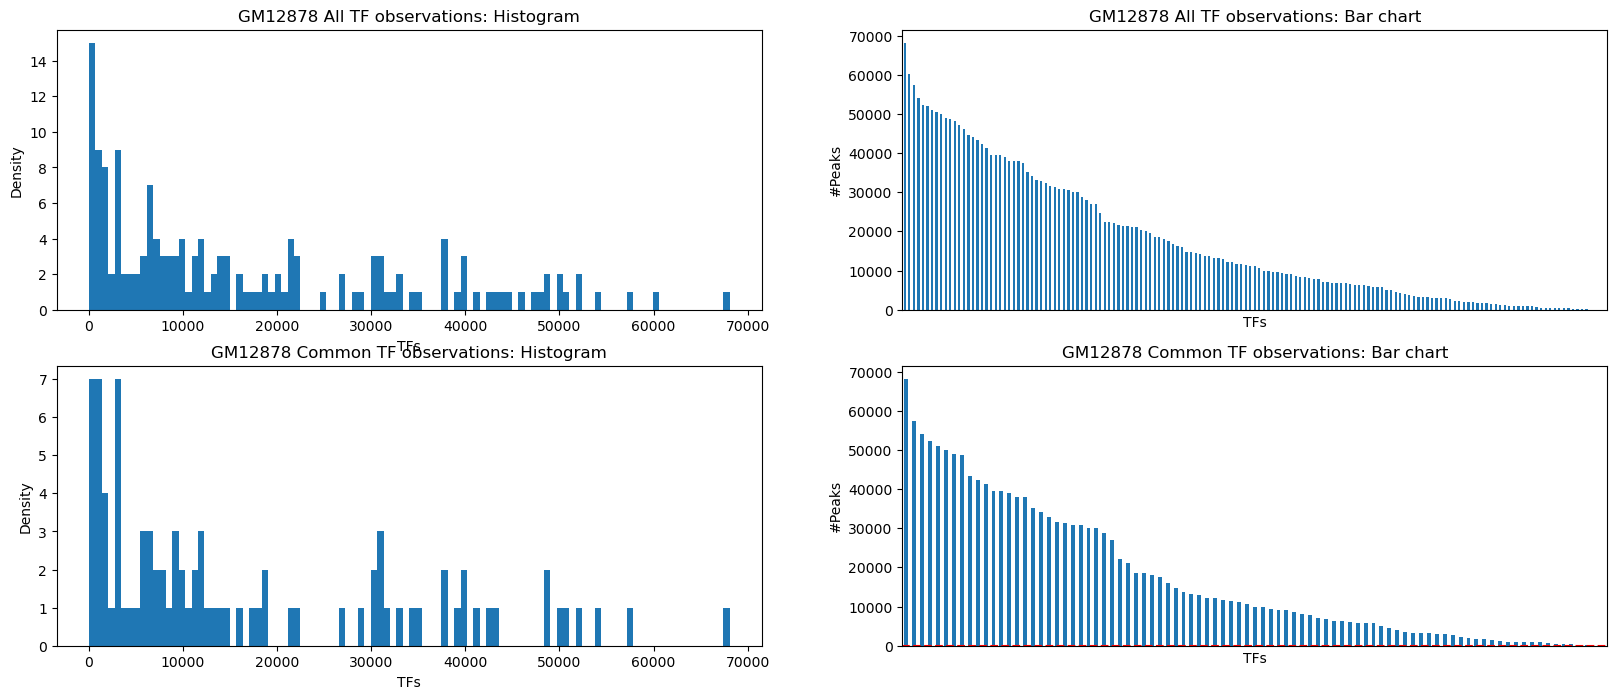

------------------------------------
200466/490366 of the ATAC-seq peaks have at least one ChIP peak
In total, there are 1524792 ChIP observations over 89 TFs
done


In [55]:
chip_file=f"../../../footprint_programs/remap22/remap2022_GM12878_nr_macs2_hg38_v1_0.bed"
_formatChIPinfo("GM12878", chip_file, jasparTFs, obs_cutoff=0)

9230156 /pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_Hep-G2_nr_macs2_hg38_v1_0.bed
437757 /pollard/data/projects/aseveritt/encode_snatacseq/03_peakcalls/HEPG2_filt_500bp.exclusion.bed
6772311 tmp.bed
For the 285 TFs in REMAP for HEPG2, 131 overlap with the jaspar db.
Of those 131 common TFs, 131 have > 0 observations.


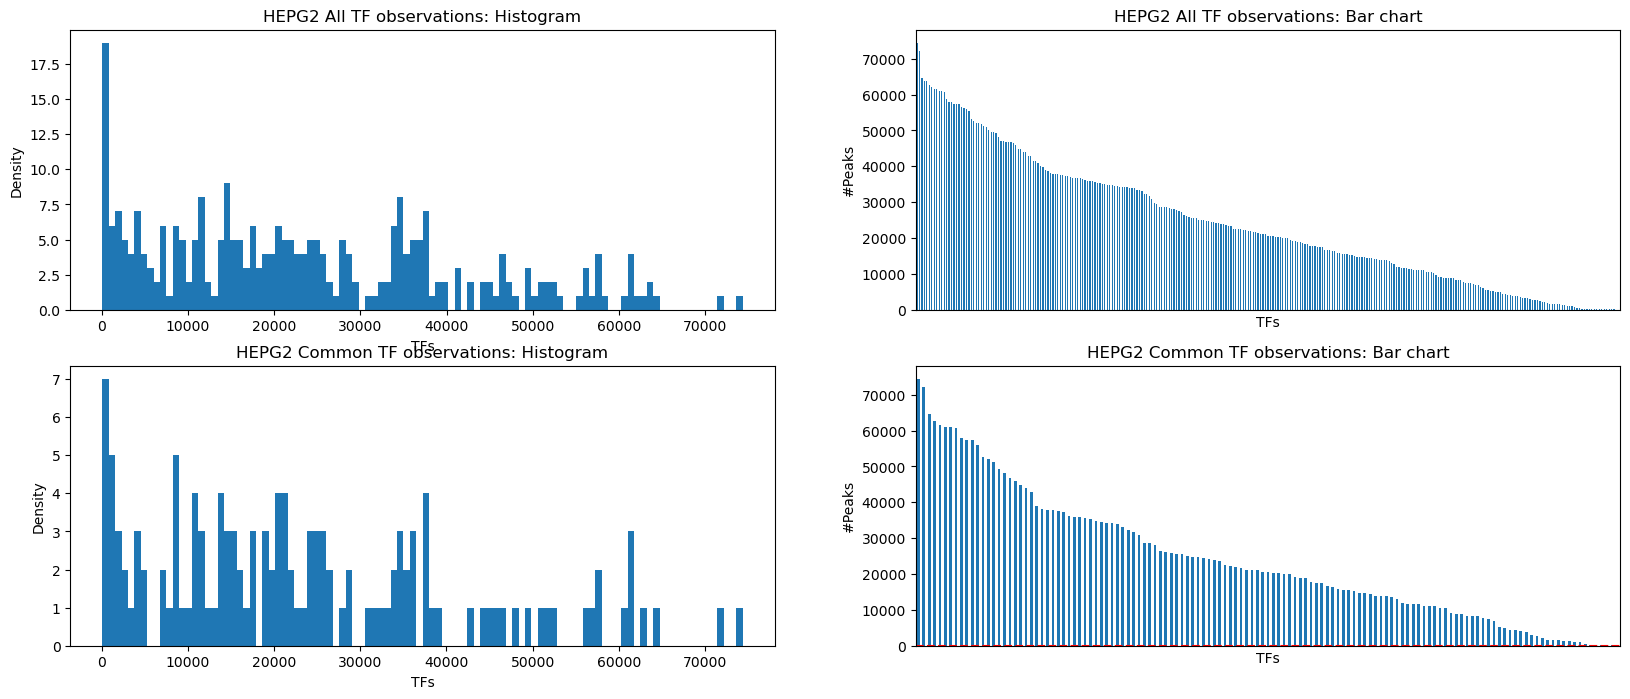

------------------------------------
245456/437757 of the ATAC-seq peaks have at least one ChIP peak
In total, there are 3127579 ChIP observations over 131 TFs
done


In [56]:
chip_file=f"../../../footprint_programs/remap22/remap2022_Hep-G2_nr_macs2_hg38_v1_0.bed"
_formatChIPinfo("HEPG2", chip_file, jasparTFs, obs_cutoff=0)

9936638 /pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_K-562_nr_macs2_hg38_v1_0.bed
497621 /pollard/data/projects/aseveritt/encode_snatacseq/03_peakcalls/K562_filt_500bp.exclusion.bed
6372402 tmp.bed
For the 413 TFs in REMAP for K562, 165 overlap with the jaspar db.
Of those 165 common TFs, 165 have > 0 observations.


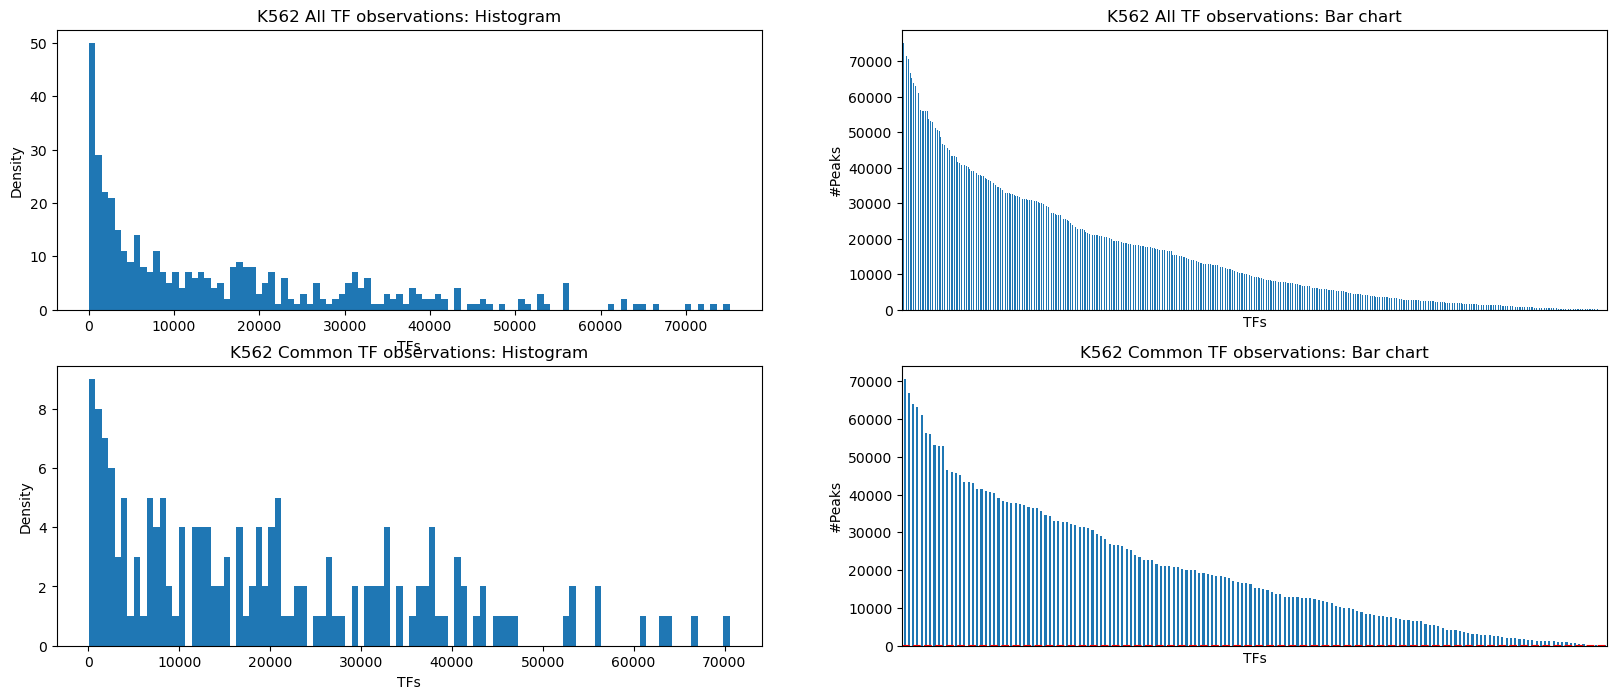

------------------------------------
300483/497621 of the ATAC-seq peaks have at least one ChIP peak
In total, there are 3234362 ChIP observations over 165 TFs
done


In [57]:
chip_file=f"../../../footprint_programs/remap22/remap2022_K-562_nr_macs2_hg38_v1_0.bed"
_formatChIPinfo("K562", chip_file, jasparTFs, obs_cutoff=0)

5495637 /pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_MCF-7_nr_macs2_hg38_v1_0.bed
377429 /pollard/data/projects/aseveritt/encode_snatacseq/03_peakcalls/MCF7_filt_500bp.exclusion.bed
3580473 tmp.bed
For the 167 TFs in REMAP for MCF7, 78 overlap with the jaspar db.
Of those 78 common TFs, 78 have > 0 observations.


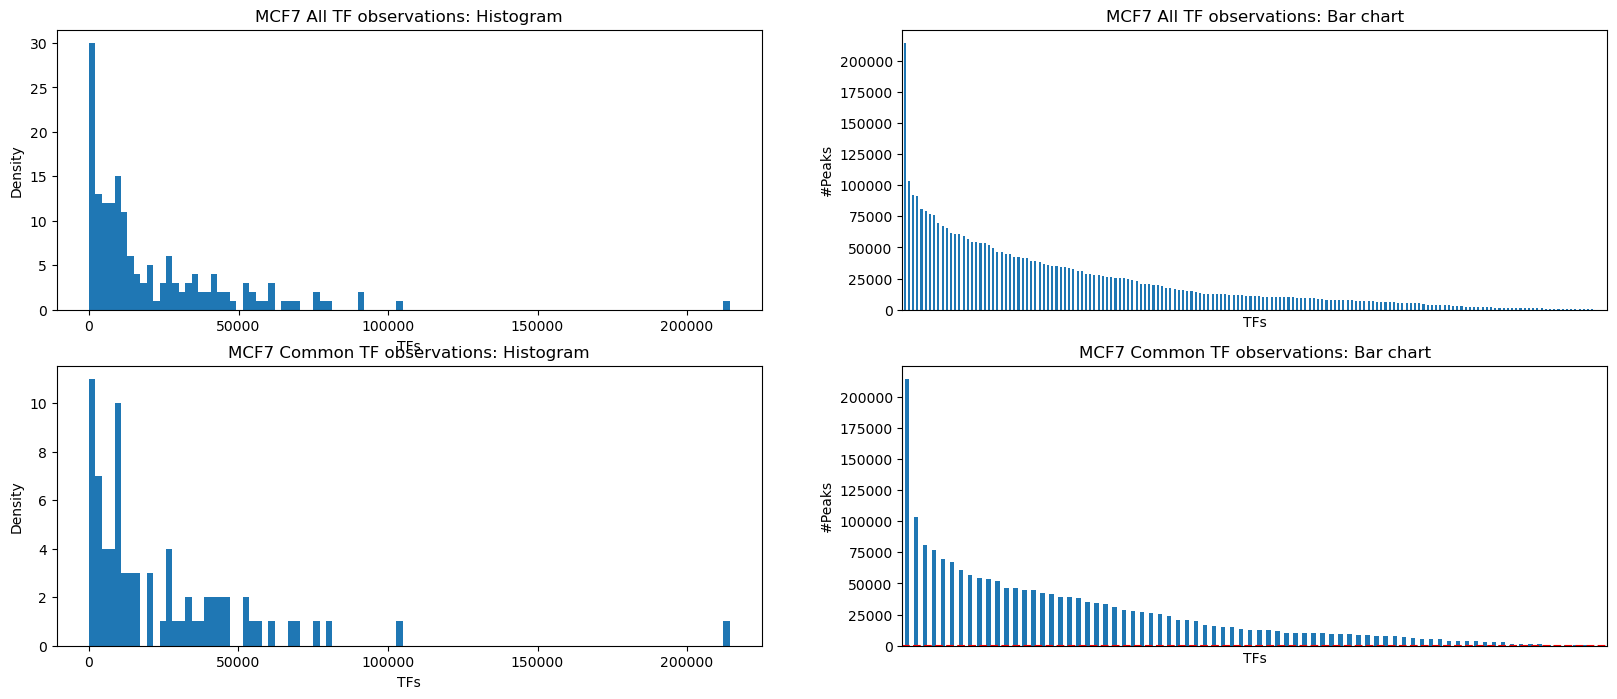

------------------------------------
283858/377429 of the ATAC-seq peaks have at least one ChIP peak
In total, there are 1933192 ChIP observations over 78 TFs
done


In [58]:
chip_file=f"../../../footprint_programs/remap22/remap2022_MCF-7_nr_macs2_hg38_v1_0.bed"
_formatChIPinfo("MCF7", chip_file, jasparTFs, obs_cutoff=0)

1237899 /pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_SK-N-SH_nr_macs2_hg38_v1_0.bed
435216 /pollard/data/projects/aseveritt/encode_snatacseq/03_peakcalls/SKNSH_filt_500bp.exclusion.bed
878237 tmp.bed
For the 44 TFs in REMAP for SKNSH, 30 overlap with the jaspar db.
Of those 30 common TFs, 30 have > 0 observations.


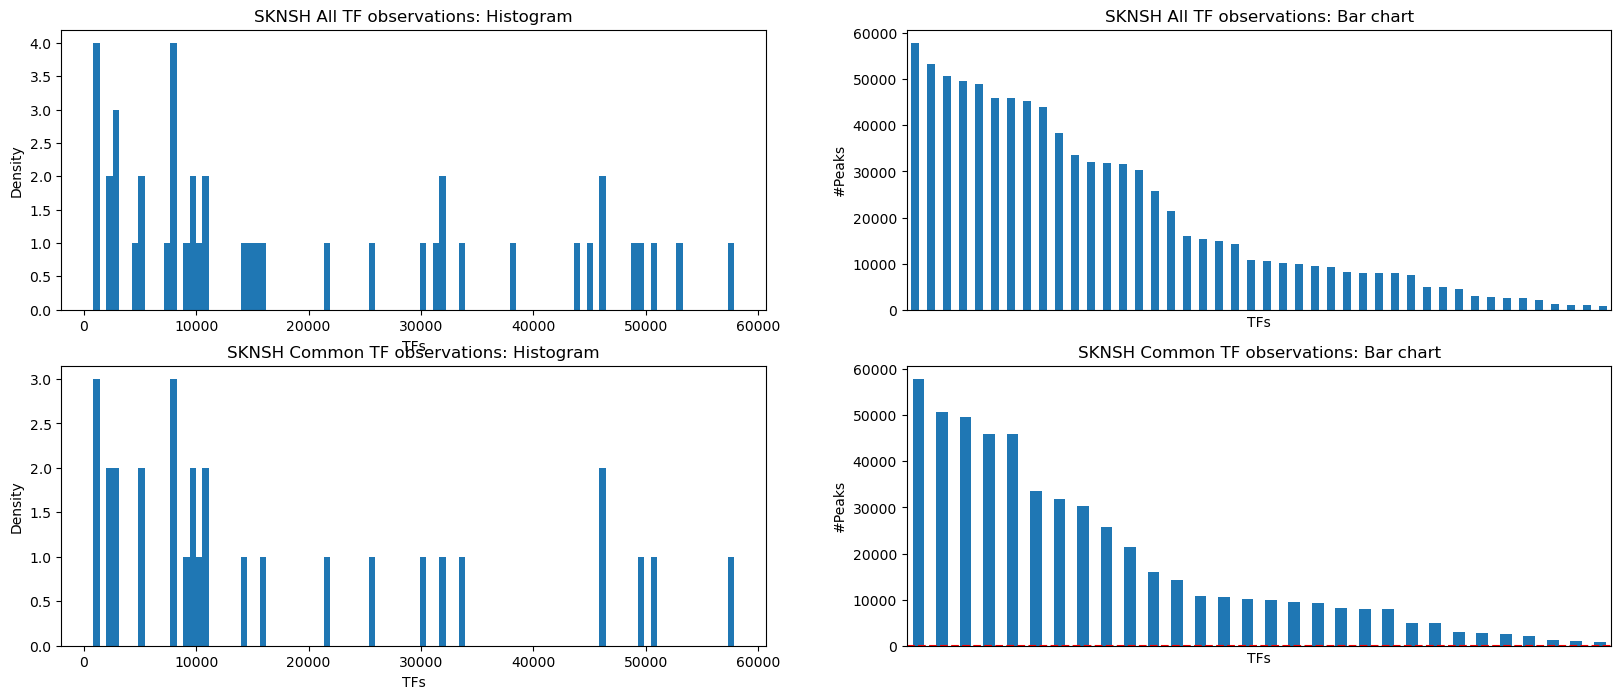

------------------------------------
155903/435216 of the ATAC-seq peaks have at least one ChIP peak
In total, there are 530920 ChIP observations over 30 TFs
done


In [59]:
chip_file=f"../../../footprint_programs/remap22/remap2022_SK-N-SH_nr_macs2_hg38_v1_0.bed"
_formatChIPinfo("SKNSH", chip_file, jasparTFs, obs_cutoff=0)

# 2. What ChIP'd TFs have reasonably accurate PWMs? <a class="anchor" id="second-bullet"></a>
- #1. Profiled TF to its PWM
- #2. Profiled TF to its PWM with shuffled count values.
- #3. Profiled TF to all other PWMs.

In [ ]:
## makes the pwm_metrics.csv files. 

##NOTE THIS OPERATES ON THE FOOTPRINT BED FILES WHICH ARE NOT FILTERED FOR TOBIAS AND PRINT. 
## THIS ONLY WORKS FOR PWM-MATCHING (AND HINT)

In [387]:
def _getContingencyMatrix(df, edf):
    #1. Profiled TF to its PWM
    #2. Profiled TF to its PWM with shuffled row values. 
    #3. Profiled TF to all other PWMs.
    
    df_observed = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    df_observed = df_observed.reindex(edf.index, axis=0, fill_value=0) #only rows matter, not columns. 
    odf = df_observed.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize
    odf_shuffled = odf.apply(lambda x: np.random.permutation(x), axis=0)
    
    res = []
    for tf in edf.columns:
        chip = edf[tf]
        chip_1 = chip == 1
        chip_0 = chip == 0
        
        for motif in odf.columns:
            for foot, analysis_type in zip([odf[motif], odf_shuffled[motif]], ["real", "shuffled"]) :
                foot_1 = foot == 1
                foot_0 = foot == 0
                
                res.append({
                    'TP': np.sum(chip_1 & foot_1),
                    'FP': np.sum(chip_0 & foot_1),
                    'FN': np.sum(chip_1 & foot_0),
                    'TN': np.sum(chip_0 & foot_0),
                    'total_TFBS': foot_1.sum(),
                    'ChIPd_TF': tf,
                    'PWM': motif,
                    'analysis': analysis_type
                })
                
    return pd.DataFrame(res)


def _getExpectedMatrix(cl):
    df_expected = pd.read_csv(f"../11_chip/{cl}/chip.mat", sep=",", index_col="region_atac")
    commonTFs = df_expected.columns.tolist()
    edf = df_expected.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize
    atac_regions = set(df_expected.index)
    return edf, commonTFs, atac_regions
    

def _getObservedMatrix(infile, peak_list, tf_list):
    df = pd.read_csv(infile, sep="\t")
    df = df.loc[df["region_atac"].isin(peak_list)] 
    df = df.loc[df["motif"].isin(motif_list)] 
    return df


def _getMatchedMotifs(chipTFs):
    infile="../05_footprinting/program_input_files/jaspar2022_motifs_to_clusters.txt.gz"
    jasparTFs = pd.read_csv(infile, sep=" ", header=None, usecols = [0], names=["motif"])
    
    jasparTFs["tf"] = jasparTFs["motif"].str.split('_').str[0].str.upper()
    
    def tf_match(tf):
        parts = tf.split("::") if "::" in tf else [tf]
        return int(any(p in chipTFs for p in parts))
    
    jasparTFs["flag"] = jasparTFs["tf"].apply(tf_match)
    
    return set(jasparTFs[jasparTFs["flag"] ==1]["motif"])

    

def _process_chunk(args):
    cl, t = args #cellline, tool
    print(cl, t)

    #SET-UP
    data_dir = f"../06_dataquality/{t}/cleaned/" #baseline files. 
    outdir = f"../11_chip/{cl}/"
    outfile = f"{outdir}/{t}_metrics.csv"
    
    all_files = [x for x in os.listdir(data_dir) if x.endswith(".bed")]
    files = [f for f in all_files if cl in f]
    Path(outdir).mkdir(parents=True, exist_ok=True) 

    #READ IN EXPECTED DATAFRAME
    edf, chipTFs, atac_regions = _getExpectedMatrix(cl)
    common_motifs = _getMatchedMotifs(chipTFs)

    for f_foot in files:
        #READ IN OBSERVED DATAFRAME
        name = re.sub('.bed', '', f_foot, count=1)
        print(f"working on: {name}")
        df = pd.read_csv(f"{data_dir}/{f_foot}", sep="\t")
        df = df.loc[df["region_atac"].isin(atac_regions) & df["motif"].isin(common_motifs)]
        cont_df = _getContingencyMatrix(df, edf)
        cont_df["file"] = name
        
    cont_df.to_csv(outfile, index=False)
    
    return


def main():
    #multiprocessing is overkill here, but keeping format consistent with section below
    from multiprocessing import Pool
    import random
    cell_lines = ["HEPG2", "K562", "MCF7", "SKNSH", "GM12878"]
    tools = ["pwm"]
    
    tasks = [(cl, tool) for cl in cell_lines for tool in tools]
    
    with Pool(processes=4) as pool: 
        pool.map(_process_chunk, tasks)
        
    print("done")
    return

#main()

In [ ]:
## makes the motif_performance.csv files. 

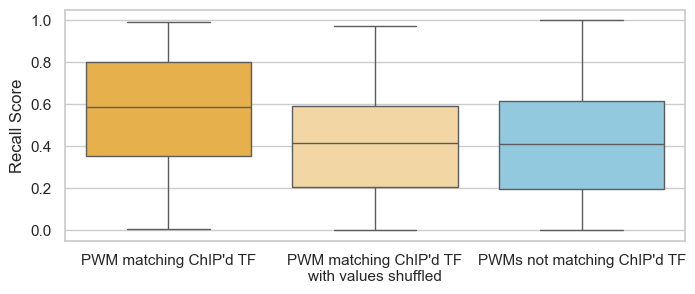

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

def _calc_scores(df):
    
    def _safe_divide(numerator, denominator):
        return np.where(denominator == 0, np.nan, numerator / denominator)
    
    tp, fp, fn, tn = df['TP'], df['FP'], df['FN'], df['TN']
    precision = _safe_divide(tp, tp + fp)
    recall    = _safe_divide(tp, tp + fn)
    f1        = _safe_divide(tp, tp + 0.5 * (fp + fn))
    fpr       = _safe_divide(fp, fp + tn)

    return float(precision), float(recall), float(f1), float(fpr), float(recall)

def tf_match(group):
    tf = group["ChIPd_TF"]
    motif = group["PWM"].split("_")[0]
    if "::" in motif:
        parts = motif.split("::")
        if any(p == tf for p in parts):
            return "match"
        else:
            return "mismatch"
    else:
        if tf == motif:
            return "match"
        else:
            return "mismatch"



dfs = []
for cl in ["HEPG2", "K562", "SKNSH", "MCF7", "GM12878"]:
    ddir = f"../11_chip/{cl}"
    df = pd.read_csv(f"{ddir}/pwm_metrics.csv.gz", sep=",")
    df[["precision", "recall", "f1", "fpr", "recall"]] = df.apply(_calc_scores, axis=1, result_type='expand')
    df["comp_category"] = df.apply(tf_match, axis=1)
    
    tmp = df[(df["comp_category"] == "mismatch") & (df["analysis"] == "real")][["recall"]]
    tmp["cat"] = "allPWMs"
    dfs.append(tmp)
    
    tmp = df[(df["comp_category"] == "match") & (df["analysis"] == "real")][["recall"]]
    tmp["cat"] = "MatchedPWMs"
    dfs.append(tmp)

    tmp = df[(df["comp_category"] == "match") & (df["analysis"] == "shuffled")][["recall"]]
    tmp["cat"] = "MatchedPWMs-shuffled"
    dfs.append(tmp)
    
tmp = pd.concat(dfs)


sns.set(style='whitegrid')
fig = plt.figure(figsize=(8,3))
gs = GridSpec(1,1, figure=fig)

ax0 = fig.add_subplot(gs[0])
sns.boxplot(data=tmp, x="cat", y="recall", hue="cat", ax=ax0,
               order=["MatchedPWMs", "MatchedPWMs-shuffled", "allPWMs"],
              palette={"MatchedPWMs":"#FFB733", "allPWMs":"skyblue", "MatchedPWMs-shuffled":"#FFDA97"})

ax0.set_ylabel("Recall Score")
ax0.set_xlabel("")
ax0.set_xticks(ax0.get_xticks())
ax0.set_xticklabels(["PWM matching ChIP'd TF", "PWM matching ChIP'd TF\nwith values shuffled", "PWMs not matching ChIP'd TF"])
plt.show()

In [3]:
def _select_good_pwms(group):
    min_f1 = 0.05
    min_recall = 0.4

    #mean of all non-match PWMs (center blue dot)
    mean_all_pwms = group[(group["comp_category"] == "mismatch") & (group["analysis"] == "real")]["f1"].mean()    

    pwm_scores = {}
    for pwm in group[(group["comp_category"] == "match")]["PWM"].unique(): #TFs can have multiple PWMs, so for each one.
        sub = group[(group["PWM"] == pwm) & (group["comp_category"] == "match")]
        
        recall_pwm_val  = sub[(sub["analysis"] == "real")]["recall"].values[0]    #get recall of PWM
        f1_pwm_val      = sub[(sub["analysis"] == "real")]["f1"].values[0]        #get f1 of PWM
        f1_pwm_shuffled = sub[(sub["analysis"] == "shuffled")]["f1"].values[0]    #get f1 of PWM w/counts shuffled

        #if recall is larger than minimum, and the max f1 score is for the real PWM. then add to selected list. 
        if (recall_pwm_val > min_recall) & (max(mean_all_pwms, f1_pwm_shuffled, f1_pwm_val, min_f1) == f1_pwm_val):
            pwm_scores[pwm] = f1_pwm_val - f1_pwm_shuffled

    #if there are elements, return the one with the highest delta
    if pwm_scores:
        return max(pwm_scores, key=pwm_scores.get)
    else:
        return None

        
def _makebigOlePointPlot(df, cl, tf_decisions, metric="f1"):
    tmp = df[(df["comp_category"] == "mismatch") & (df["analysis"] == "real")]
    tmp = tmp.groupby("ChIPd_TF")[metric].agg(["mean", "std"]).rename(columns={"mean": metric, "std": "error"}).reset_index()
    tmp.columns = ["ChIPd_TF", "metric_mean", "metric_std"]
    
    tmp2 = df[(df["comp_category"] == "match") & (df["analysis"] == "real")][["ChIPd_TF", "PWM", metric]]
    tmp2.columns = ["ChIPd_TF", "PWM", "real"]
    
    tmp3 = df[(df["comp_category"] == "match") & (df["analysis"] == "shuffled")][["ChIPd_TF", "PWM", metric]]
    tmp3.columns = ["ChIPd_TF", "PWM", "shuffled"]
    
    plot_df = pd.merge(pd.merge(tmp, tmp2, on="ChIPd_TF"), tmp3, on=["ChIPd_TF","PWM"])
    plot_df["yaxis"] = plot_df.ChIPd_TF + " (" + plot_df.PWM + ")"
    #plot_df["delta"] = plot_df.real - plot_df.f1_mean
    #custom_order = plot_df.sort_values("delta", ascending=False)["yaxis"].tolist()
    
    custom_order = plot_df.sort_values("real", ascending=False)["yaxis"].tolist()
    plot_df["yaxis"] = pd.Categorical(plot_df["yaxis"], categories=custom_order, ordered=True)
    
    sns.set(font_scale=0.8, style='whitegrid')
    fig = plt.figure(figsize=(8,30))
    gs = GridSpec(1,1, figure=fig, wspace = 0.5, hspace=0.5)
    ax0 = fig.add_subplot(gs[0])
    
    
    sns.scatterplot(data=plot_df, y="yaxis", x="metric_mean", color="skyblue", ax=ax0, label="All PWMs", zorder=2)
    ax0.errorbar(plot_df["metric_mean"], plot_df["yaxis"], xerr=plot_df["metric_std"],
                 fmt='none', ecolor='skyblue', capsize=2, linewidth=1.5, zorder=2)

    sns.scatterplot(data=plot_df, y="yaxis", x="real", ax=ax0, 
                    edgecolor='orange', marker='o', linewidth=1, facecolors='orange',
                    label="PWM for ChIP'd TF", zorder=3)
    
    sns.scatterplot(data=plot_df, y="yaxis", x="shuffled", ax=ax0,
                    edgecolor='orange', marker='o', linewidth=1, facecolors='none',
                    label="PWM for ChIP'd TF with counts shuffled", zorder=3)


    
    keptTFs = tf_decisions[~tf_decisions.isnull().any(axis=1)]["name"].tolist()
    for tick in ax0.get_yticklabels():
        if tick.get_text() not in keptTFs:
            tick.set_color("grey")
    
    ax0.set_title(f"{cl}: PWM specificity for REMAP2022 ChIP'd TF")
    ax0.set_xlabel(f"{metric} Scores")
    ax0.set_ylabel("")
    
    
    miny, nexty, *_, maxy = ax0.get_yticks()
    eps = (nexty - miny) / 1 
    ax0.set_ylim(maxy+eps, miny-eps)
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(Line2D([], [], color='black', lw = 2)); labels.append('retained in analysis')
    handles.append(Line2D([], [], color='grey', lw = 2)); labels.append('removed from analysis')
    plt.legend(handles, labels)
    sns.move_legend(ax0, "upper left", bbox_to_anchor=(1, 1))
    legend = ax0.get_legend()
    for text in legend.get_texts():
        if text.get_text() == "removed from analysis":
            text.set_color("grey")
            
    ax0.xaxis.grid(False)
    plt.show()
    return



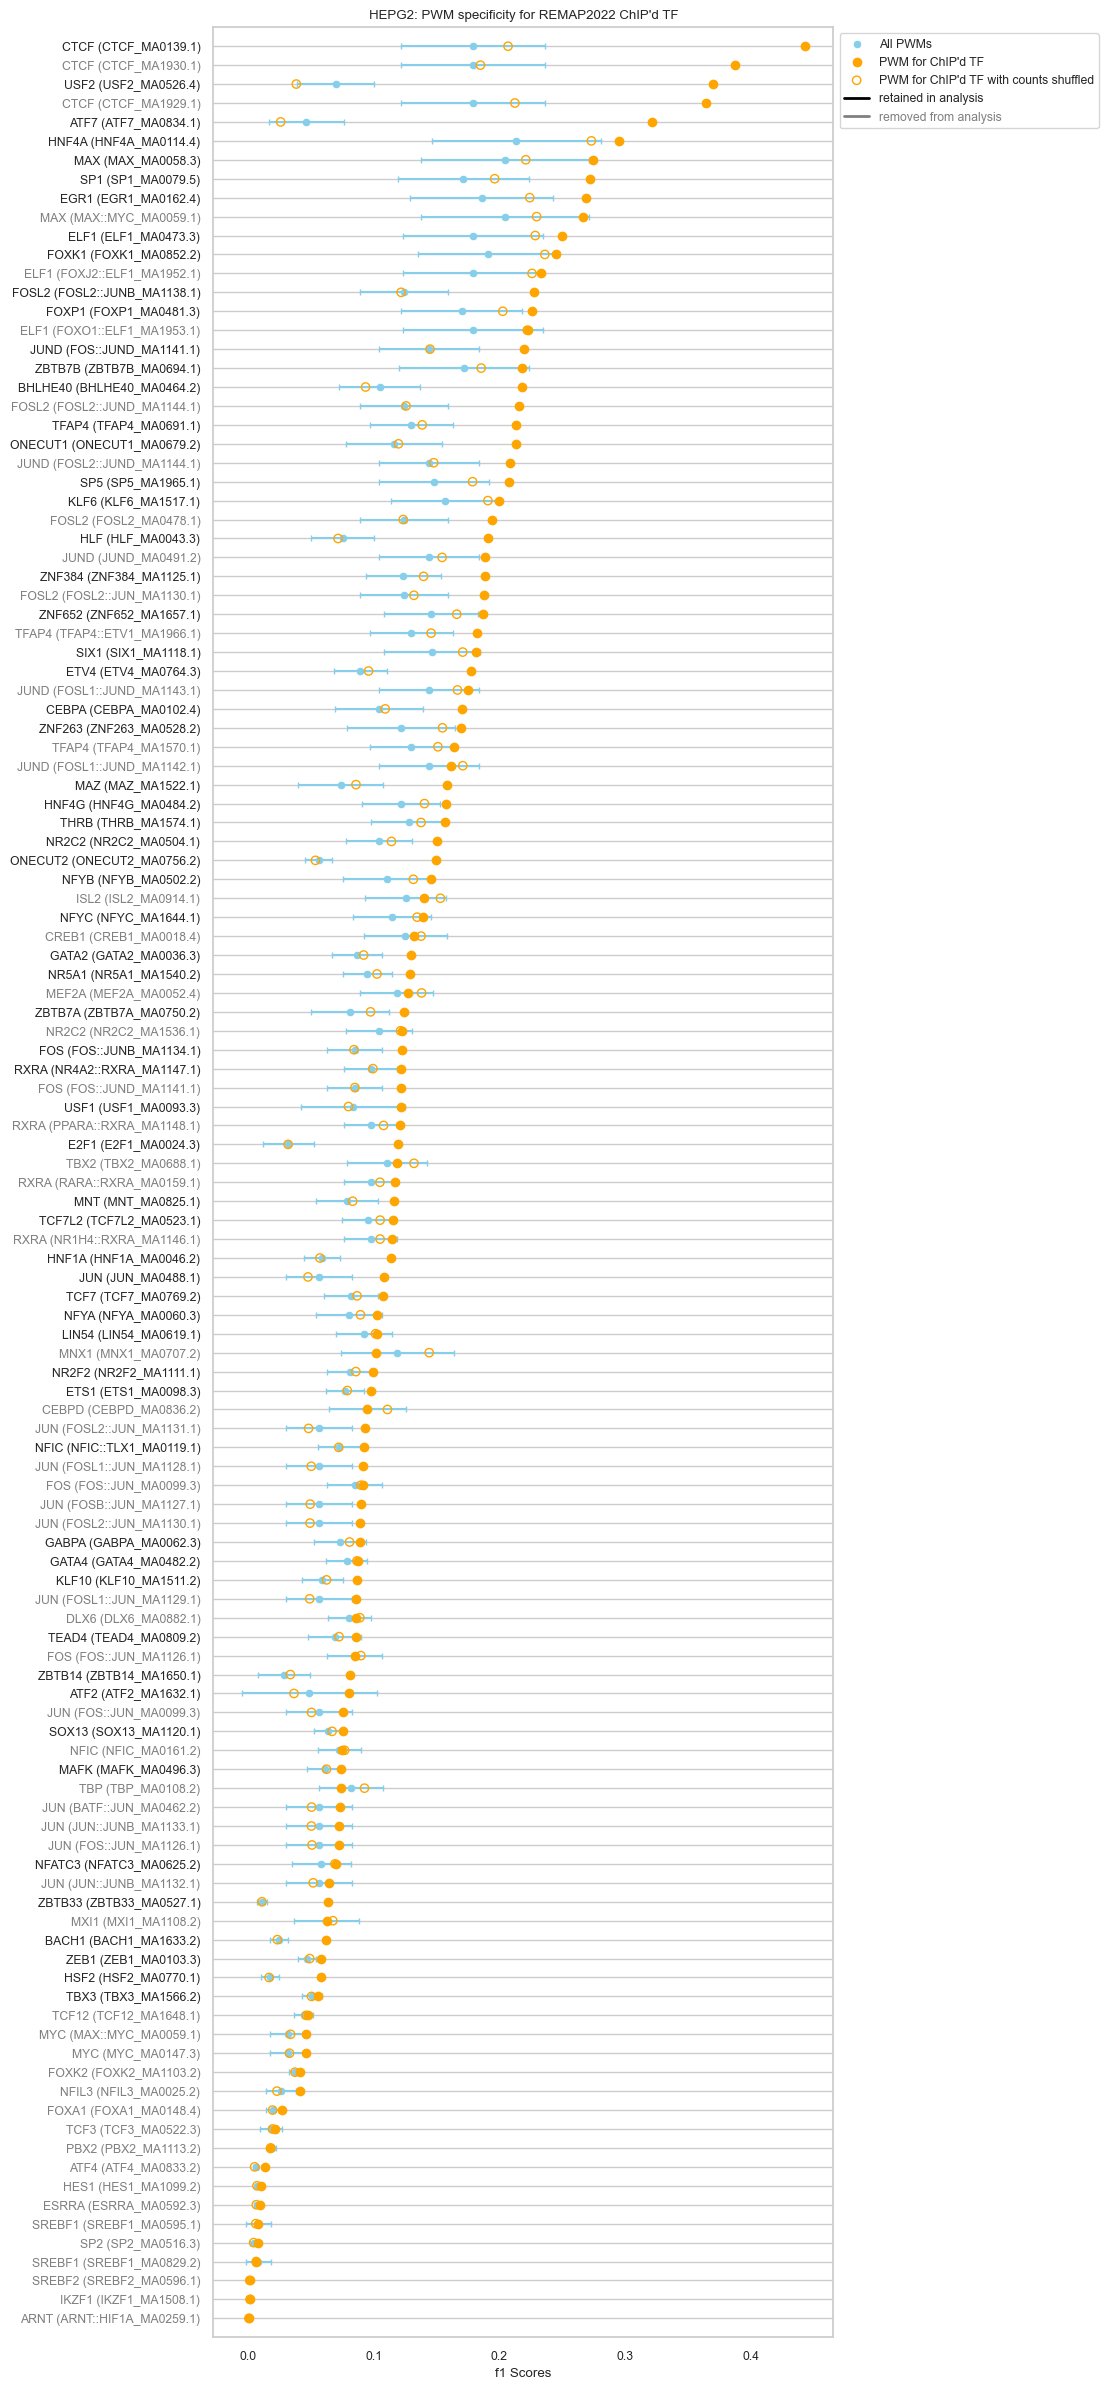

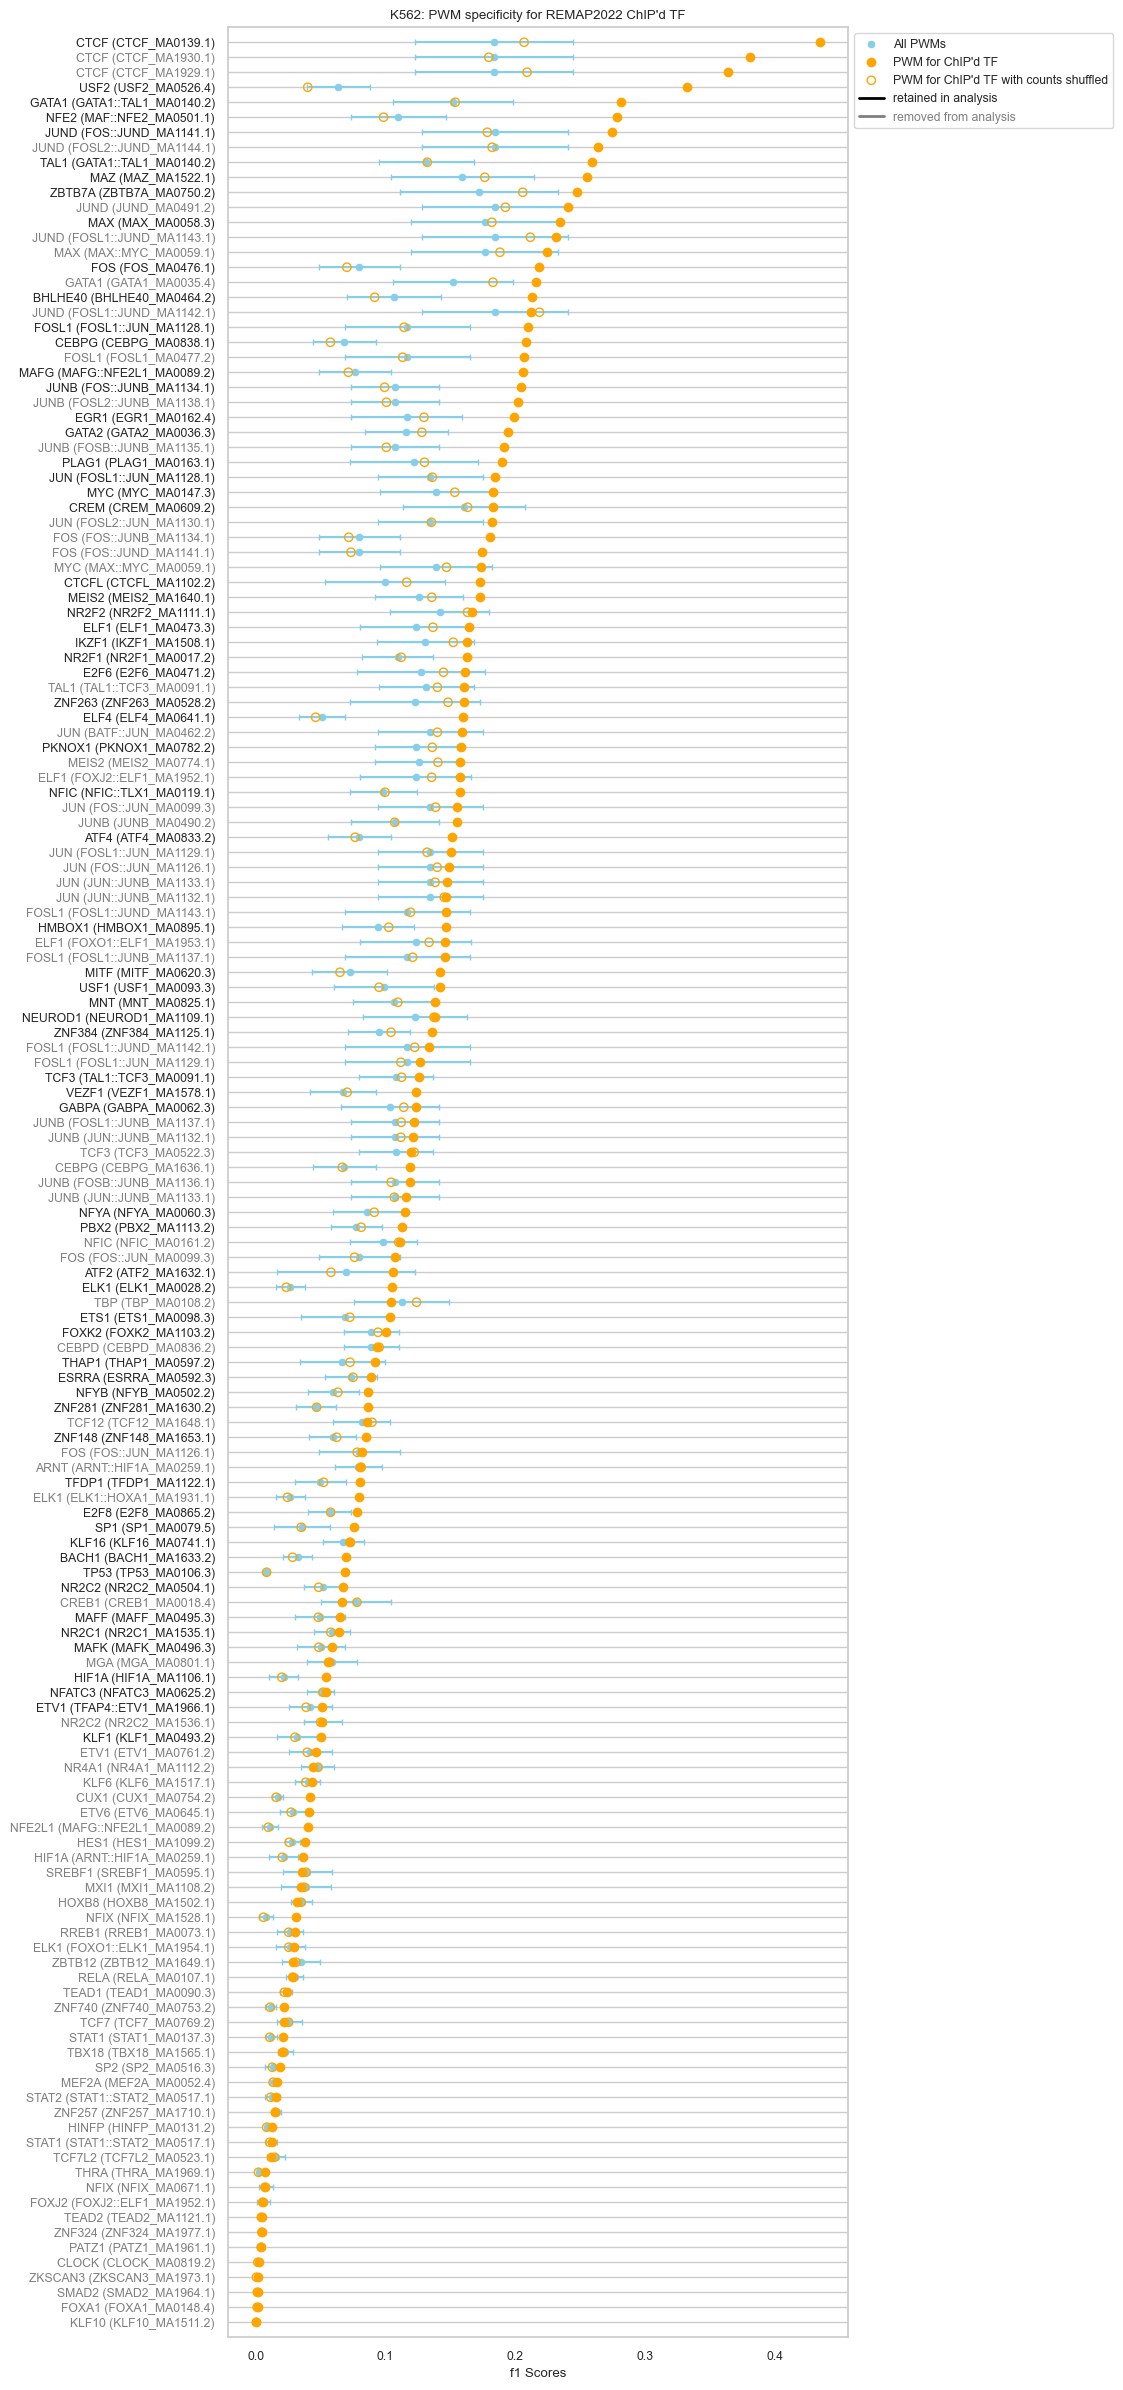

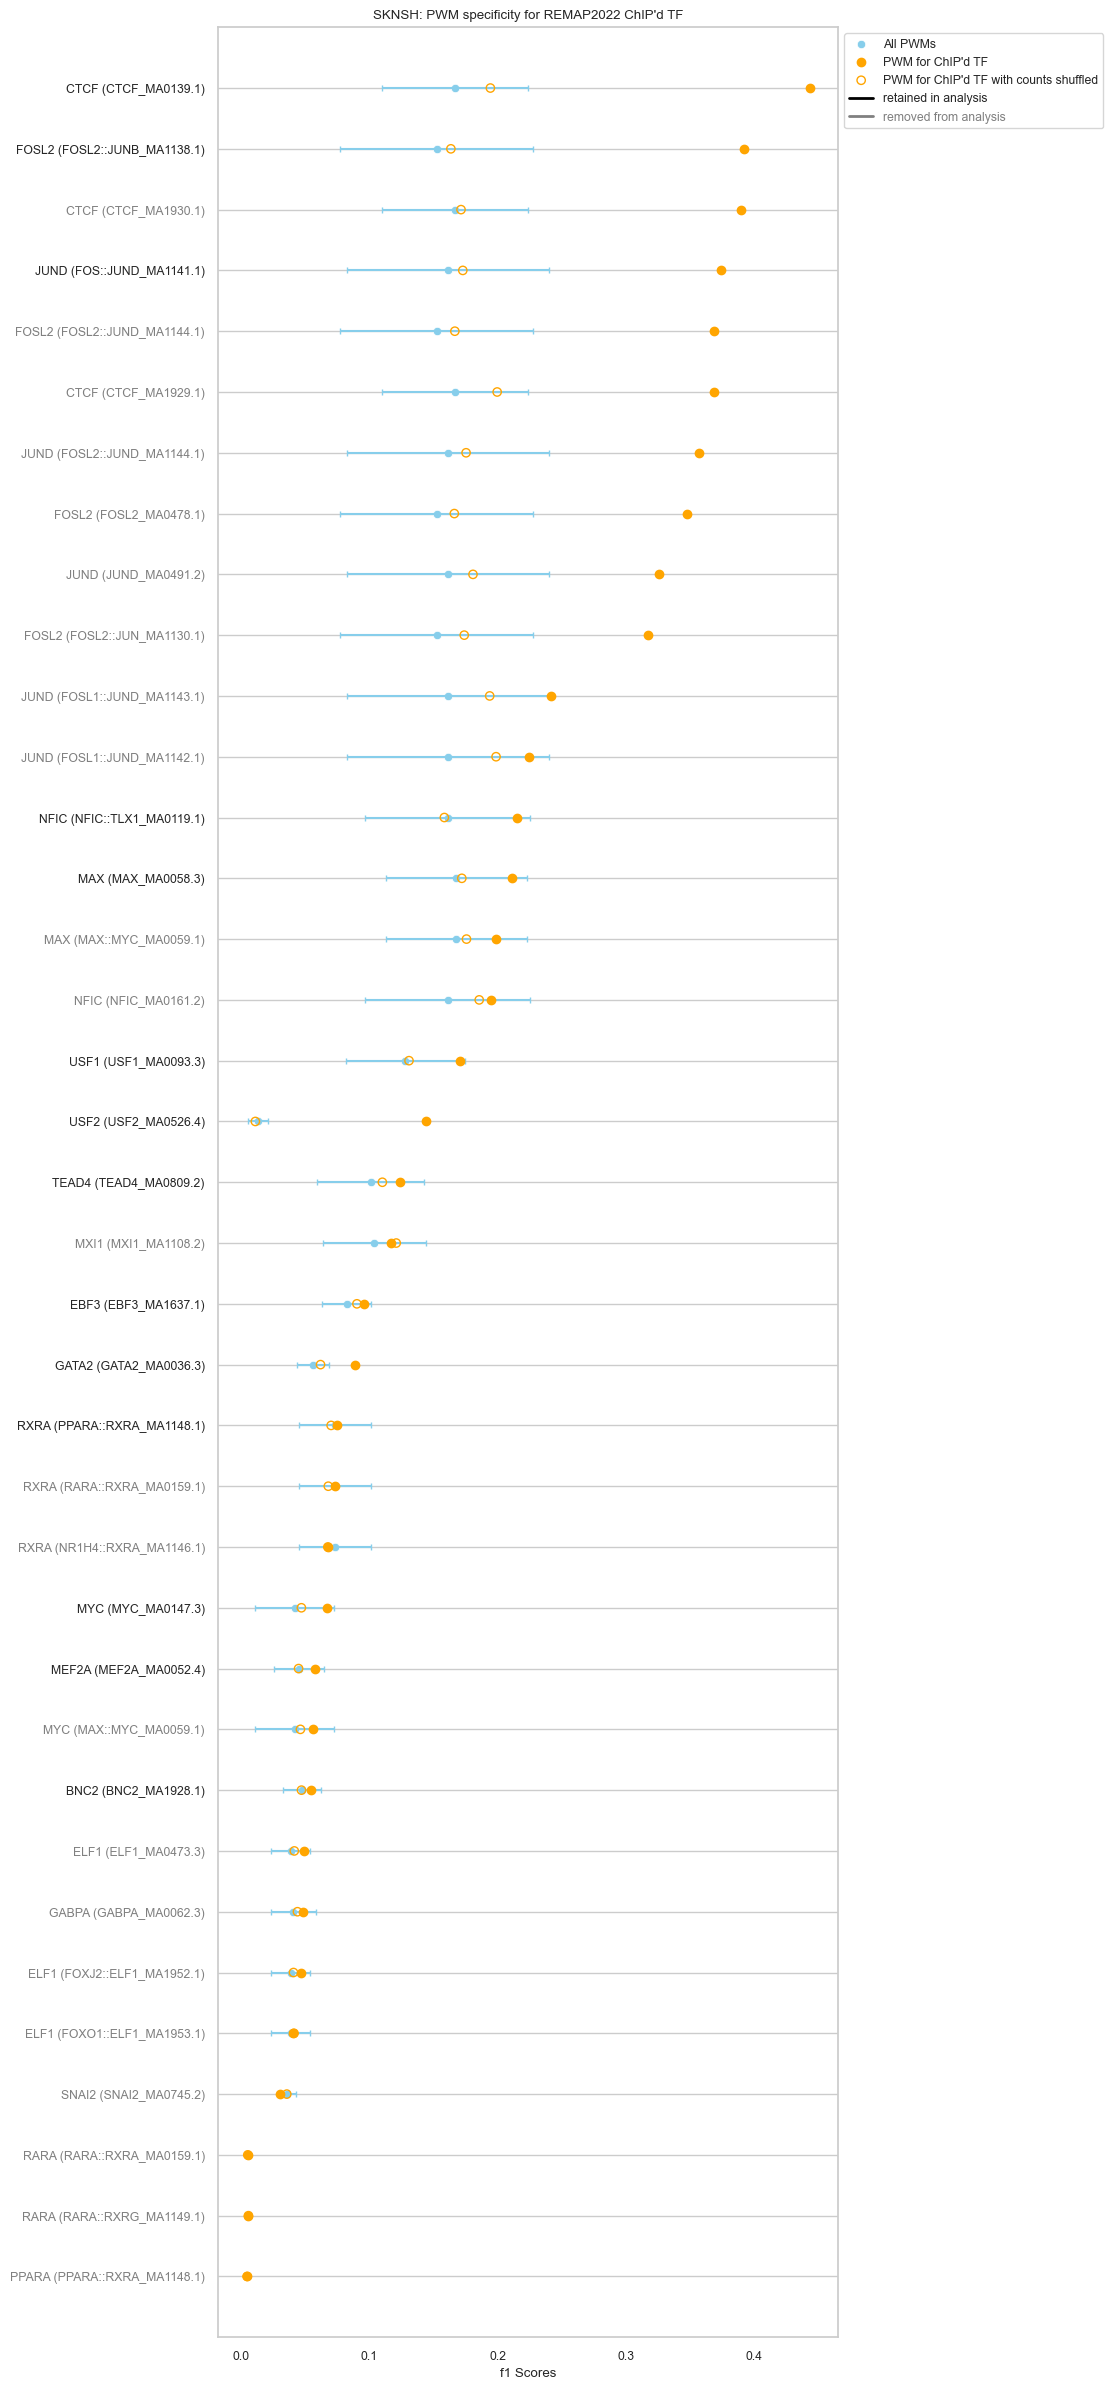

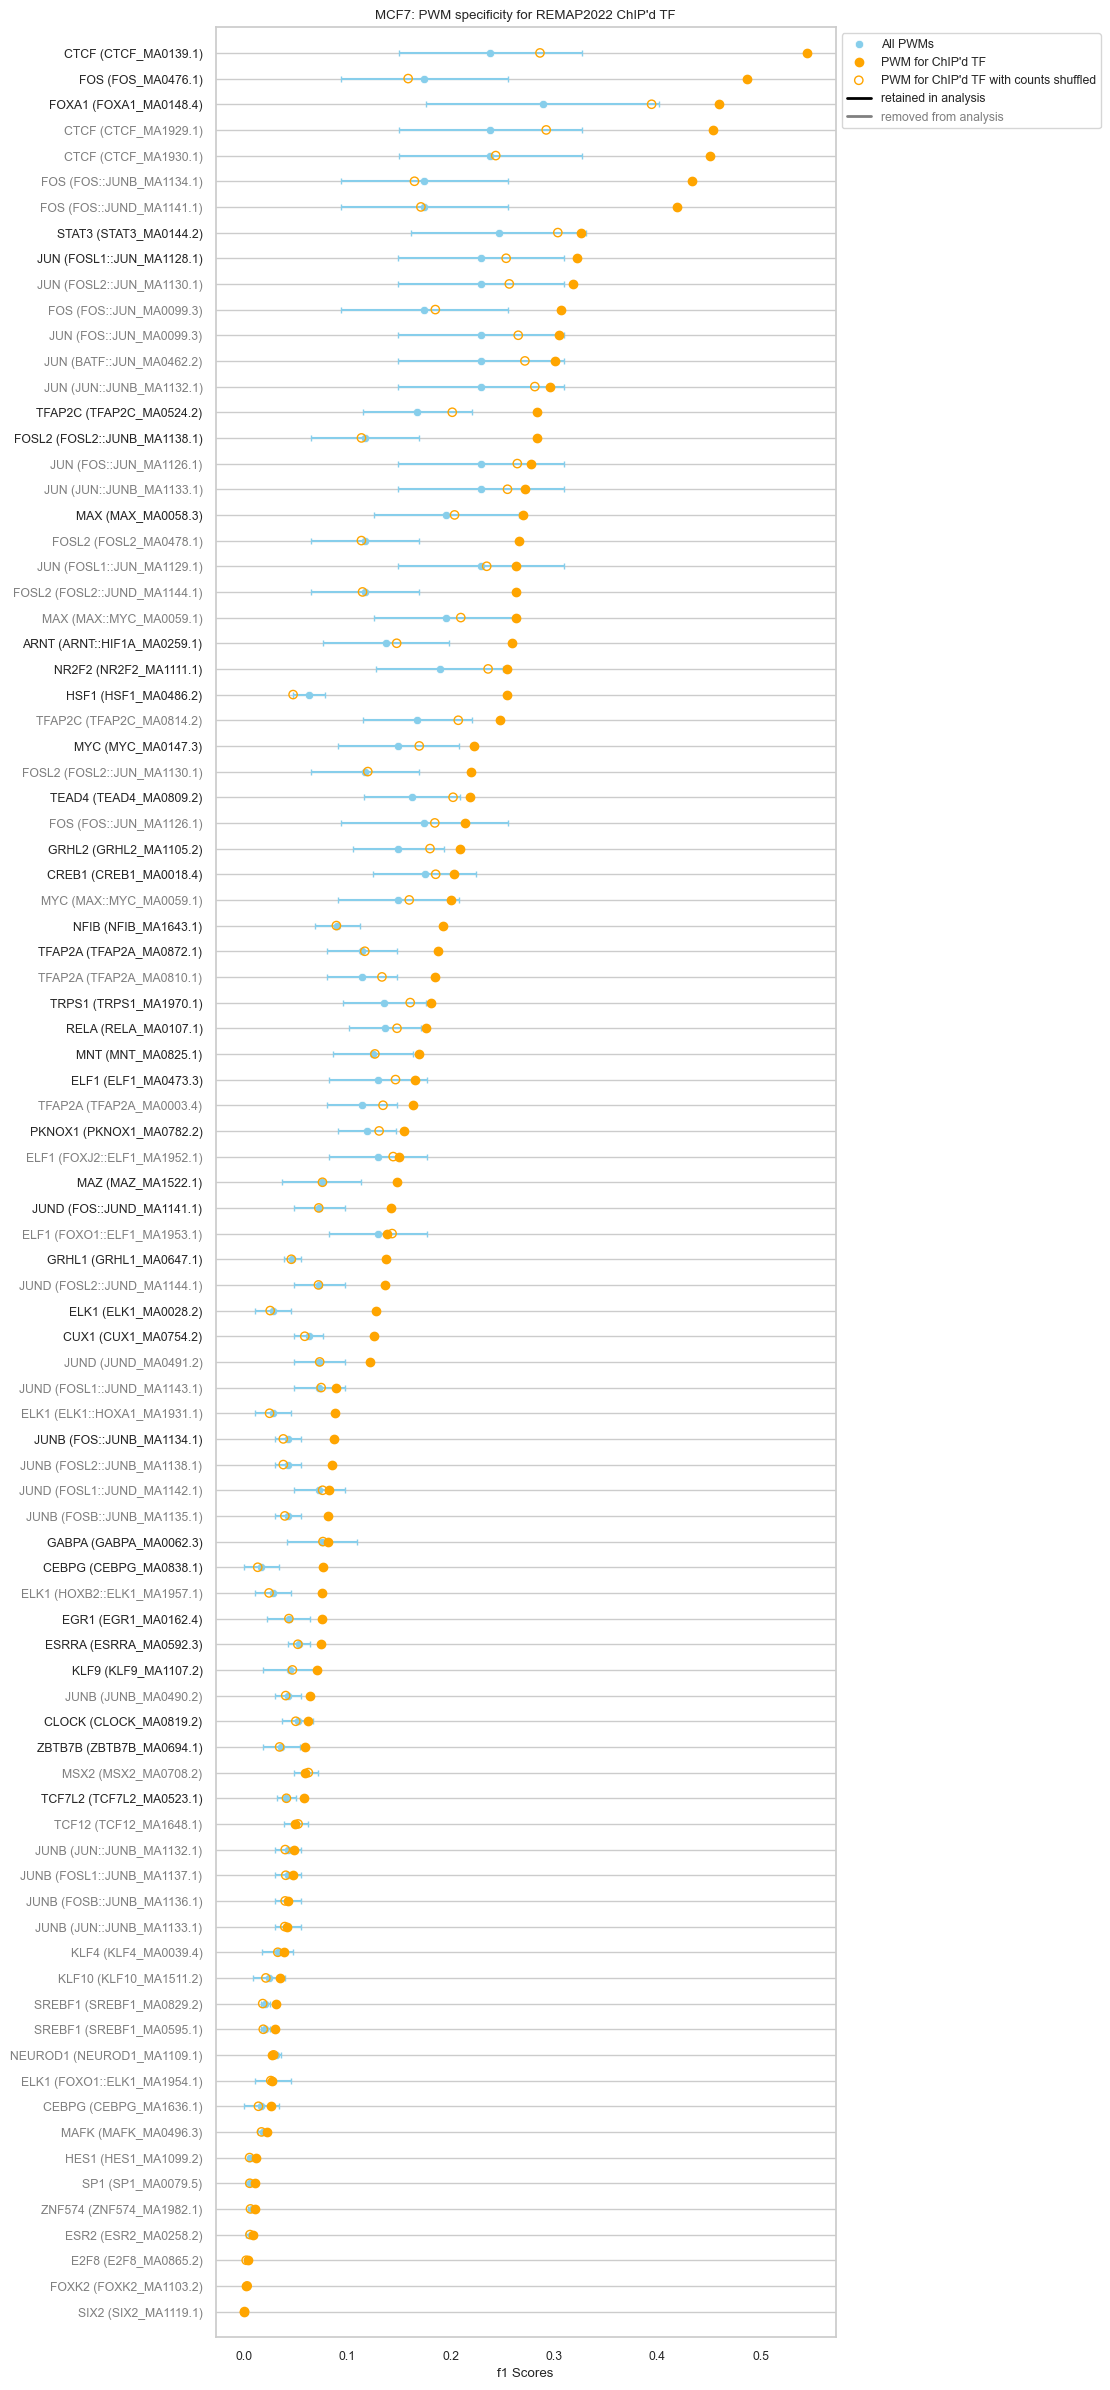

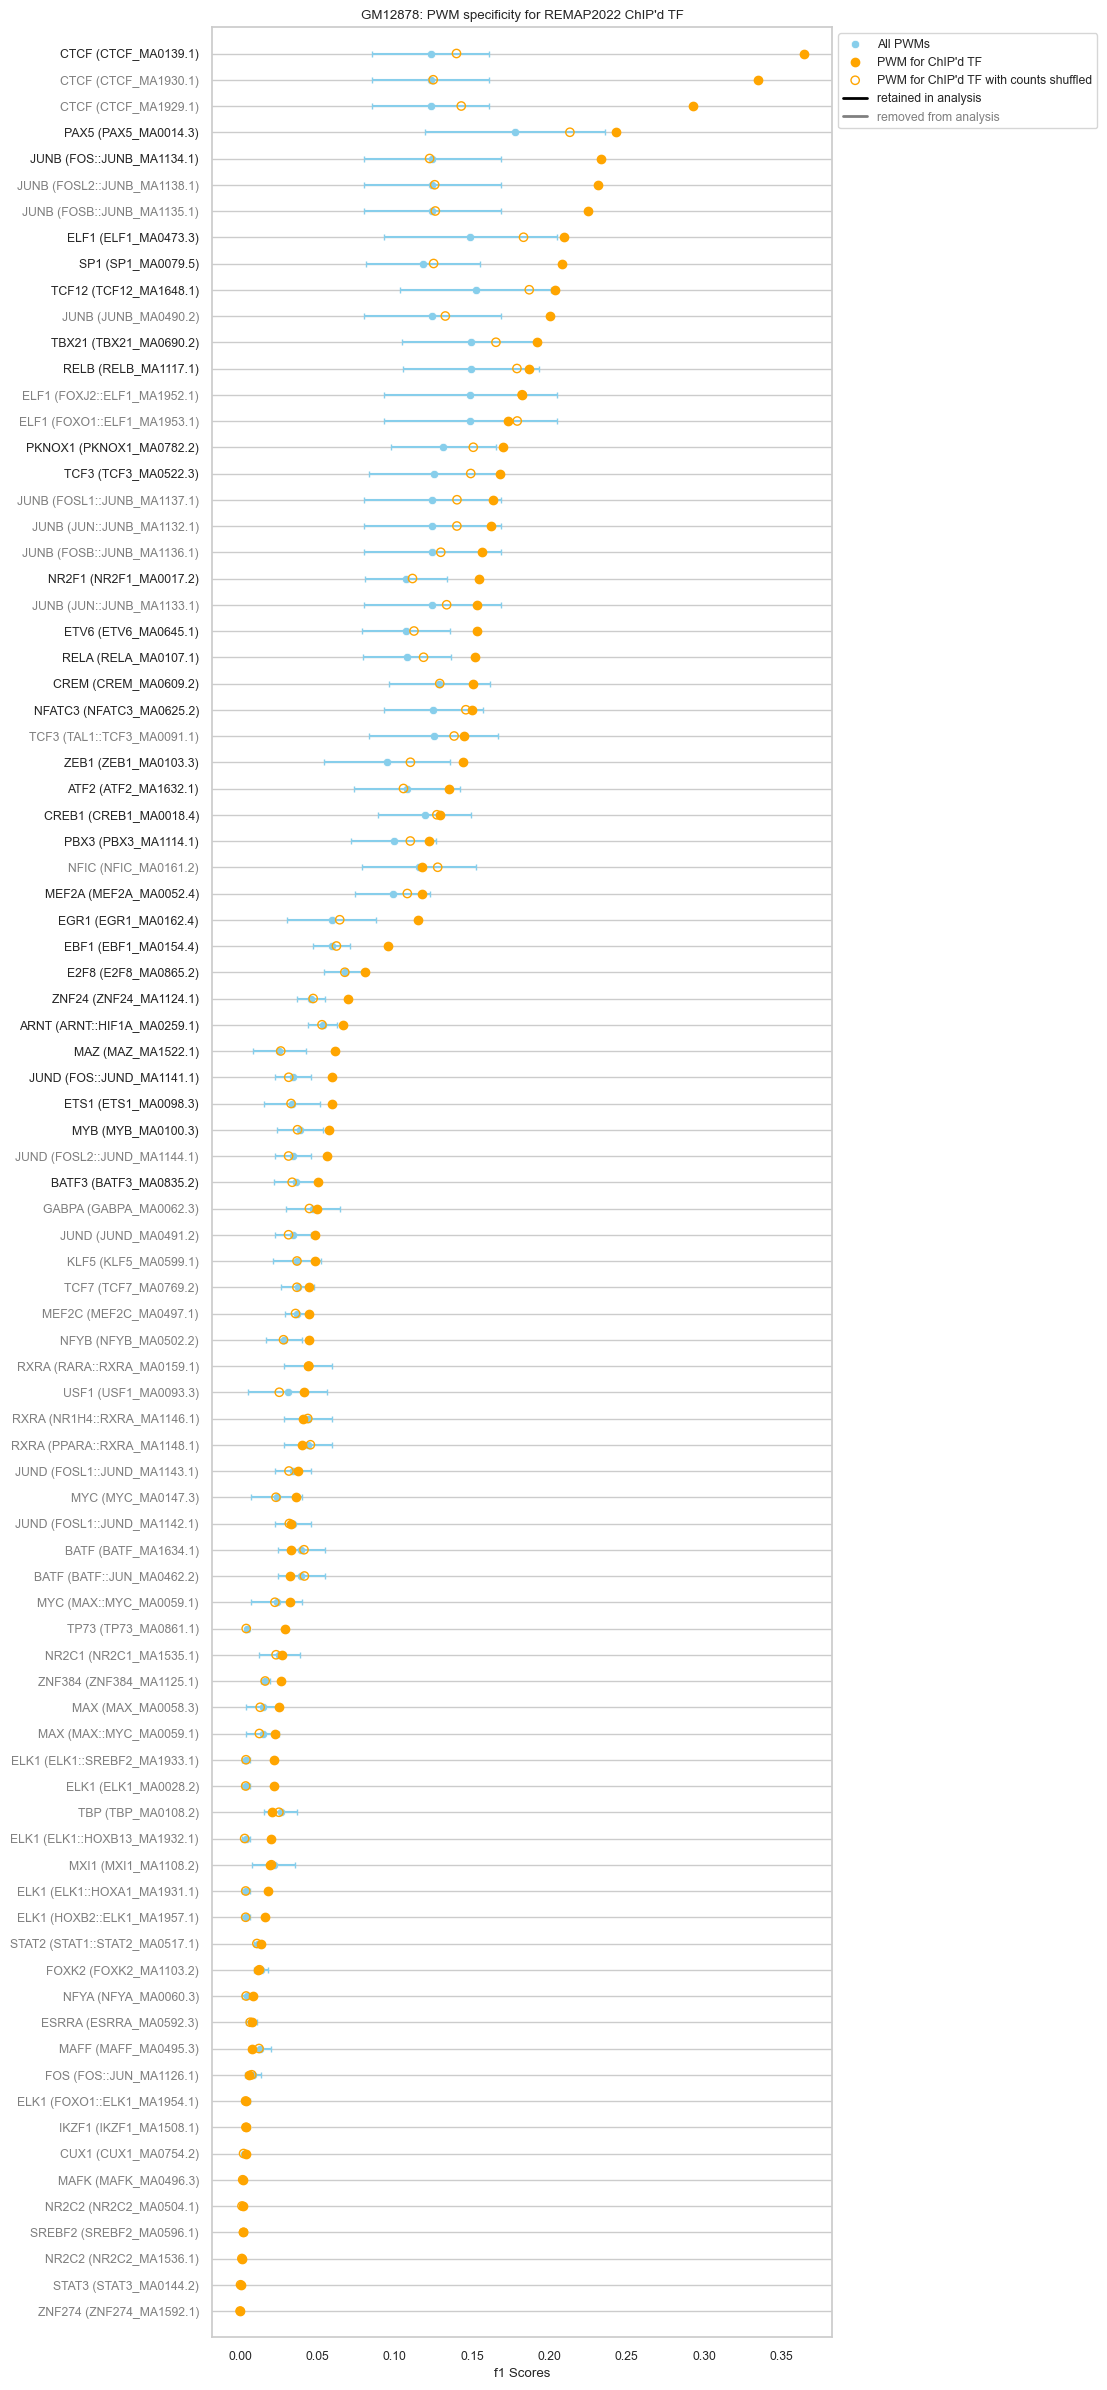

In [4]:
for cl in ["HEPG2", "K562", "SKNSH", "MCF7", "GM12878"]:
    ddir = f"../11_chip/{cl}"
    df = pd.read_csv(f"{ddir}/pwm_metrics.csv.gz", sep=",")
    df[["precision", "recall", "f1", "fpr", "recall"]] = df.apply(_calc_scores, axis=1, result_type='expand')
    df["comp_category"] = df.apply(tf_match, axis=1)
    #display(df)
    
    #output which ones are reassonably accurate and input those below for programs. 
    tf_decisions = df.groupby("ChIPd_TF").apply(_select_good_pwms, include_groups=False).reset_index()
    tf_decisions.columns = ["ChIPd_TF", "BestMotif"]
    tf_decisions["name"] = tf_decisions["ChIPd_TF"] + " (" + tf_decisions["BestMotif"] + ")"
    tf_decisions.to_csv(f"{ddir}/motif_performance.csv.gz", index=False)
    
    cond1 = (df["comp_category"] == "match")
    cond2 = (df["analysis"] == "real")
    cond3 = (df["recall"] < 0.4)
    
    _makebigOlePointPlot(df[~(cond1 & cond2 & cond3)], cl, tf_decisions, metric="f1")

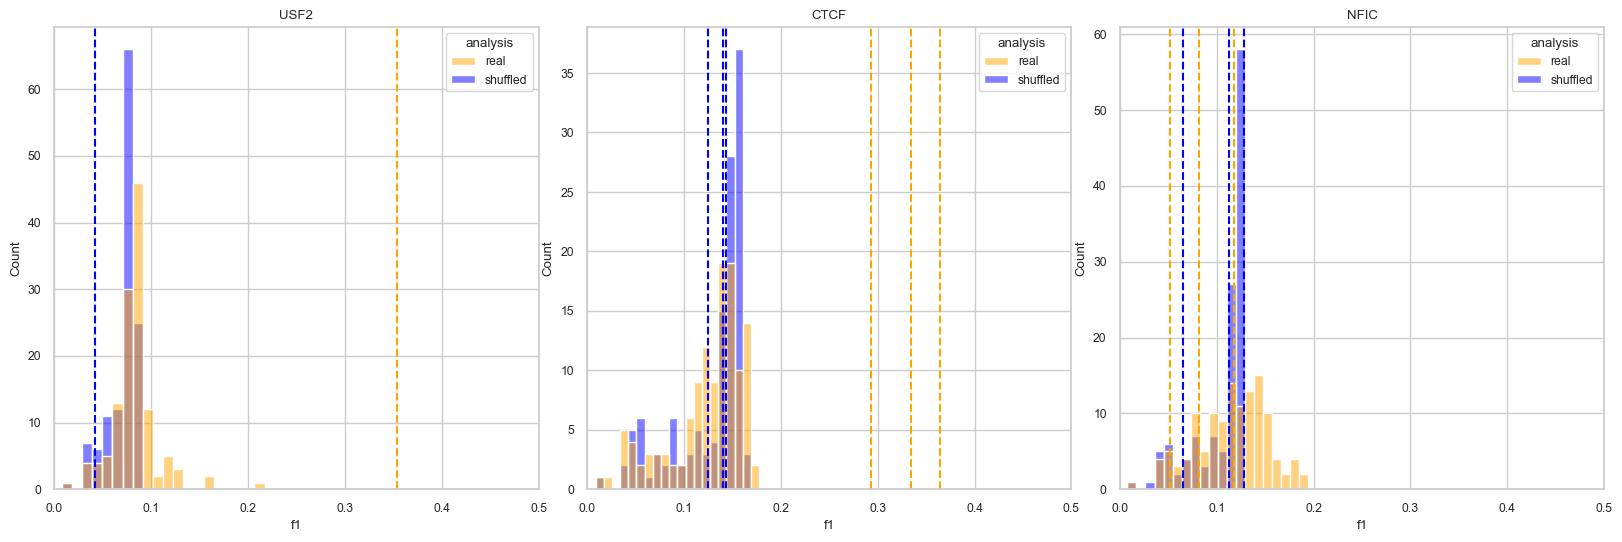

In [9]:
def _quickplot(df, tf, ax):
    metric = "f1"
    pal={"shuffled": "blue", "real": "orange"}
    mymax=0.5
    
    sns.histplot(data=df[(df["ChIPd_TF"] == tf) & (df["comp_category"] == "mismatch")], 
                 hue="analysis", palette = pal,
                 x=metric, bins=20, ax=ax)
    for i, rows in df[(df["ChIPd_TF"] == tf) & (df["comp_category"] == "match")].iterrows():
        plt.axvline(rows[metric], color=pal[rows["analysis"]], linestyle="dashed")
    ax.set_title(tf)
    ax.set_xlim(0,mymax)
    return ax


fig = plt.figure(figsize=(20,6))
gs = GridSpec(1, 3, figure=fig, wspace = 0.1, hspace=0.1)

ax0 = fig.add_subplot(gs[0])
ax0 = _quickplot(df, "USF2", ax0)

ax0 = fig.add_subplot(gs[1])
ax0 = _quickplot(df, "CTCF", ax0)

ax0 = fig.add_subplot(gs[2])
ax0 = _quickplot(df, "NFIC", ax0)

plt.show()

# 3. Evaluate how analytical choices could effect performance metrics <a class="anchor" id="third-bullet"></a>
- all chip regions
- all chip regions w/ FT regions shuffled
- chip regions w/ pwm
- chip regions w/enough coverage
- all chip regions w/ FT in top X rank by score.

## 3.1 Scoring Deciles

In [11]:
def _format_binary_pivot(df, atac_regions, motifs):
    tmp_pivot = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    tmp_pivot = tmp_pivot.reindex(atac_regions, axis=0, fill_value=0) #only rows matter, not columns. 
    tmp_pivot = tmp_pivot.reindex(motifs, axis=1, fill_value=0)
    tmp_pivot = tmp_pivot.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize
    return tmp_pivot
    
    
def _get_observed(cl, tool, atac_regions, motifs):
    infile = f"../06_dataquality/{tool}/cleaned/{cl}-cellFilt.bed"
    tmp = pd.read_csv(infile, sep="\t")
    tmp = tmp.loc[tmp["region_atac"].isin(atac_regions) & tmp["motif"].isin(motifs)]

    if tool == "hint": tmp["score"] = tmp["tag_count"]
    return tmp

    
def _calc_scores(df, shuffle=False):
    def _safe_divide(numerator, denominator):
        return np.nan if denominator == 0 else round(numerator / denominator, 4)

    if shuffle:
        np.random.seed(42069)
        df["Footprinting"] = np.random.permutation(df["Footprinting"].values)
        
    chip_pos = df["ChIP"] > 0
    chip_zero = df["ChIP"] == 0
    footprint_pos = df["Footprinting"] > 0
    footprint_zero = df["Footprinting"] == 0

    tp = np.sum(chip_pos & footprint_pos)
    fp = np.sum(chip_zero & footprint_pos)
    fn = np.sum(chip_pos & footprint_zero)
    tn = np.sum(chip_zero & footprint_zero)

    precision = _safe_divide(tp, tp + fp)
    recall    = _safe_divide(tp, tp + fn)
    f1        = _safe_divide(tp, tp + 0.5 * (fp + fn))
    fpr       = _safe_divide(fp, fp + tn)

    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'total foot': np.sum(footprint_pos),
        'total chip': np.sum(chip_pos),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'shuffled': shuffle
    }


def _process_chunk(args):
    try:
        df_observed, edf, tf_zipped, tool, thresh, decile_name = args
        odf = _format_binary_pivot(df_observed, edf.index, np.unique([i[1] for i in tf_zipped]))
        
        joint = []
        for tf, motif in tf_zipped:
            local_df = pd.DataFrame({'ChIP': edf[tf].to_numpy(), 'Footprinting': odf[motif].to_numpy()})
            scores = _calc_scores(local_df.copy(), False)
            scores.update({"motif": motif, "chipd_tf": tf, "tool": tool, "threshold": thresh, "decile": decile_name})
            joint.append(scores)
        
        return joint

    except Exception as e:
        print(f"Error processing {thresh}{tool}: {e}")
        return


def _getTOBIASthresh(cl):
    infile="../08_acrosstools/tobias_thresholds.txt.gz"
    thresh_file = pd.read_csv(infile, sep=" ", header=None, names=["file", "threshold"])
    thresh_file = thresh_file.loc[thresh_file.file.str.contains("cellFilt")].copy()
    thresh_file[["cell_line", "tmp"]] = thresh_file.file.str.split('-', expand=True)
    v = thresh_file[thresh_file.cell_line == cl]["threshold"].tolist()[0]
    return v

    
def main(cell_line):
    from multiprocessing import Pool
    import random

    tasks = []
    deciles = np.linspace(0,1,11)

    #GET TF MATCHES
    motif_to_tf  = pd.read_csv(f"../11_chip/{cell_line}/motif_performance.csv.gz", sep=",")
    motif_to_tf.dropna(inplace=True)
    motif_to_tf = motif_to_tf.sort_values("ChIPd_TF")
    tf_zipped = list(zip(list(motif_to_tf["ChIPd_TF"]), list(motif_to_tf["BestMotif"])))
    
    #READ IN EXPECTED DATAFRAME (chip mat)
    df_expected = pd.read_csv(f"../11_chip/{cell_line}/chip.mat", sep=",", index_col="region_atac")
    edf = df_expected.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize

    #SET-UP IN OBSERVED FILES
    for tool, baseline_threshold in zip(["hint", "pwm", "print", "tobias"], [0, 0, 0.3, _getTOBIASthresh(cell_line)]) :
        df_observed = _get_observed(cl=cell_line, tool=tool, atac_regions=edf.index, motifs=np.unique(motif_to_tf["BestMotif"]))
        thresholds = np.quantile(df_observed["score"], deciles)

        tasks.extend([(df_observed[df_observed["score"] >= baseline_threshold], edf, tf_zipped, tool, baseline_threshold, "baseline")])
        for thresh, decile in zip(thresholds, deciles):
            tasks.extend([(df_observed[df_observed["score"] >= thresh], edf, tf_zipped, tool, thresh, f"q{int(decile*100)}")])

    print("starting tasks")
    
    with Pool(processes=25) as pool: 
        all_results = pool.map(_process_chunk, tasks)

    flat_joint = [item for sublist in all_results for item in sublist]
    joint_df = pd.DataFrame(flat_joint)
    joint_df.to_csv(f"../11_chip/{cell_line}/decile_metrics.csv", index=False)
    print("done")

# for cl in ["MCF7", "HEPG2", "K562", "SKNSH", "GM12878"]:
#     print(cl)
#     main(cl)

#Example of what table looks like
joint_df = pd.read_csv(f"../11_chip/HEPG2/decile_metrics.csv.gz")
display(joint_df)

,TP,FP,FN,TN,total foot,total chip,precision,recall,f1,fpr,shuffled,motif,chipd_tf,tool,threshold,decile
0,1231,6805,7019,422702,8036,8250,0.1532,0.1492,0.1512,0.0158,False,ATF2_MA1632.1,ATF2,hint,0.00000,baseline
1,707,1459,8066,427525,2166,8773,0.3264,0.0806,0.1293,0.0034,False,ATF7_MA0834.1,ATF7,hint,0.00000,baseline
2,778,10413,4364,422202,11191,5142,0.0695,0.1513,0.0953,0.0241,False,BACH1_MA1633.2,BACH1,hint,0.00000,baseline
3,1058,2138,26885,407676,3196,27943,0.3310,0.0379,0.0680,0.0052,False,BHLHE40_MA0464.2,BHLHE40,hint,0.00000,baseline
4,2747,6291,23604,405115,9038,26351,0.3039,0.1042,0.1552,0.0153,False,CEBPA_MA0102.4,CEBPA,hint,0.00000,baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3019,0,0,55497,382260,0,55497,NaN,0.0000,0.0000,0.0000,False,ZBTB7B_MA0694.1,ZBTB7B,tobias,30.34703,q100
3020,0,0,11028,426729,0,11028,NaN,0.0000,0.0000,0.0000,False,ZEB1_MA0103.3,ZEB1,tobias,30.34703,q100
3021,0,0,37094,400663,0,37094,NaN,0.0000,0.0000,0.0000,False,ZNF263_MA0528.2,ZNF263,tobias,30.34703,q100
3022,0,0,35012,402745,0,35012,NaN,0.0000,0.0000,0.0000,False,ZNF384_MA1125.1,ZNF384,tobias,30.34703,q100


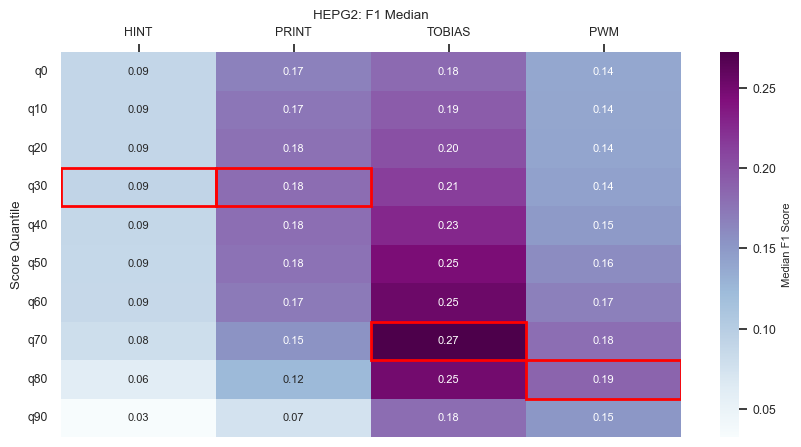

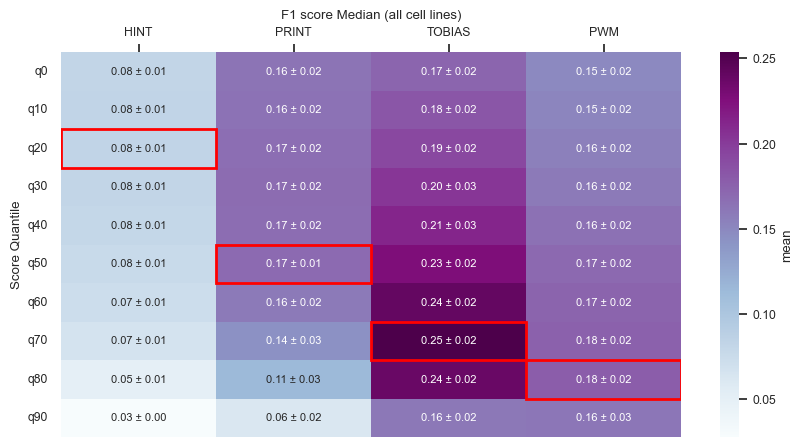

In [12]:
def _gatherTable(metric="precision"):
    def quick(cl):
        tmp = pd.read_csv(f"../11_chip/{cl}/decile_metrics.csv.gz")
        tmp["cell_line"] = cl
        return tmp
        
    df = pd.concat([quick("HEPG2"), quick("MCF7"), quick("K562"), quick("GM12878"), quick("SKNSH")])
    
    summary = (
            df[df["total foot"] != 0].groupby(["threshold", "tool", "cell_line", "decile"])[metric]
            .agg(
                  mean='mean',
                  median='median',
                  stdev='std',
                  n_observations='count'
              )
            .sort_values(['tool', 'cell_line', 'threshold'])
            .reset_index()        )
        
    summary["score_quantile"] = summary.decile
    
    return summary


def _plotHeatmap(inputdf, colorby = "median", add_column_wise_maxbox=False, add_maxbox=False):

    if colorby == "median":
        pivot_tmp = inputdf[inputdf.score_quantile !="q100"].pivot(index='score_quantile', columns='tool', values=colorby)
        inputdf["labels"] = inputdf.apply(lambda row: f"{row[colorby]:.2f}", axis=1)
        labels = inputdf[inputdf.score_quantile !="q100"].pivot(index='score_quantile', columns='tool', values="labels")
    elif colorby == "mean":
        pivot_tmp = inputdf[inputdf.score_quantile !="q100"].pivot(index='score_quantile', columns='tool', values=colorby)
        inputdf["labels"] = inputdf.apply(lambda row: f"{row['mean']:.2f} ± {row['stdev']:.2f}", axis=1)
        labels = inputdf[inputdf.score_quantile !="q100"].pivot(index='score_quantile', columns='tool', values="labels")
    else:
        print("ERROR in colorby"); return

    plot_order = ["hint", "print", "tobias", "pwm"]
    #plot_order = ["hint", "tobias", "print", "Motif Scan"]
    pivot_tmp = pivot_tmp[plot_order]
    labels = labels[plot_order]

    sns.set(font_scale=0.8, style='whitegrid')
    fig = plt.figure(figsize=(10,5))
    gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.45)
    
    ax = fig.add_subplot(gs[0])
    g = sns.heatmap(pivot_tmp, 
                    annot = labels, 
                    annot_kws={"size": 8}, fmt='',
                    ax=ax, cmap="BuPu")

    cbar = g.collections[0].colorbar
    cbar.set_label(colorby)

    if add_column_wise_maxbox:
        for i, col in enumerate(pivot_tmp.columns):
            col_idx = i
            row_idx = pivot_tmp.index.get_loc(pivot_tmp[col].idxmax())
            plt.gca().add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor='red', lw=2))

    if add_maxbox:
        max_row, max_col = pivot_tmp.values.argmax() // pivot_tmp.shape[1], pivot_tmp.values.argmax() % pivot_tmp.shape[1]
        plt.gca().add_patch(plt.Rectangle((max_col, max_row), 1, 1, fill=False, edgecolor='red', lw=2))        
    
    ax.set_xlabel("")
    ax.set_ylabel("Score Quantile")
    g.set_yticklabels(g.get_yticklabels(), rotation=0)
    
    x_labels = [label.get_text() for label in ax.get_xticklabels()]
    ax.set_xticklabels([label.upper() for label in x_labels])
    ax.xaxis.tick_top()

    return cbar, ax
   # plt.show()


summary = _gatherTable(metric="f1")
cbar, ax = _plotHeatmap(summary[(summary.cell_line == "HEPG2") & (summary.score_quantile !="baseline")].copy(), 
                        colorby = "median", 
                        add_column_wise_maxbox=True)
cbar.ax.set_ylabel(ylabel = "Median F1 Score", fontsize=8)
ax.set_title("HEPG2: F1 Median")
plt.show()

summary2 = summary.groupby(["score_quantile", "tool"])["median"].agg(mean='mean', stdev='std').reset_index()
cbar, ax = _plotHeatmap(summary2[(summary2.score_quantile !="baseline")].copy(), colorby = "mean", add_column_wise_maxbox=True)
ax.set_title("F1 score Median (all cell lines)")
plt.show()


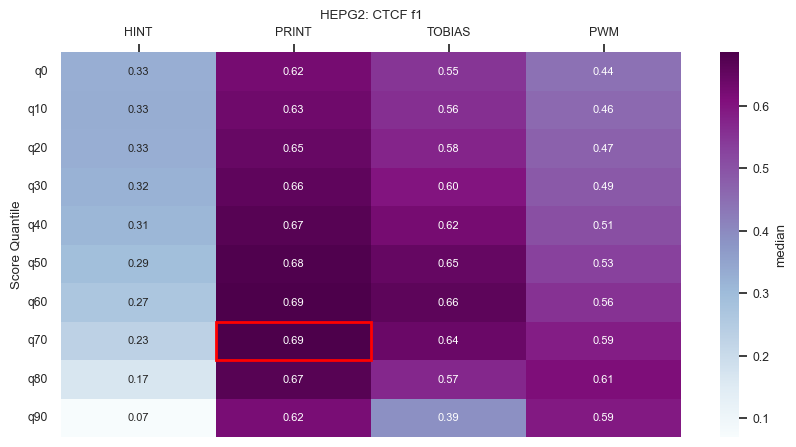

In [14]:
def quick(cl):
    tmp = pd.read_csv(f"../11_chip/{cl}/decile_metrics.csv.gz")
    tmp["cell_line"] = cl
    return tmp
    
df = pd.concat([quick("HEPG2"), quick("MCF7"), quick("K562"), quick("GM12878"), quick("SKNSH")])
df["score_quantile"] = df.decile
df["median"] = df.f1

cell_line="HEPG2"
metric="f1"

TF = "CTCF"
tmp = df[(df.chipd_tf == TF) & (df.cell_line == cell_line) & (df.score_quantile != "baseline")].copy()
cbar, ax = _plotHeatmap(tmp, colorby = "median", add_maxbox=True) 
ax.set_title(f"{cell_line}: {TF} {metric}")
plt.show()

In [17]:
def quick(cl):
    tmp = pd.read_csv(f"../11_chip/{cl}/decile_metrics.csv.gz")
    tmp["cell_line"] = cl
    return tmp
df = pd.concat([quick("HEPG2"), quick("MCF7"), quick("K562"), quick("GM12878"), quick("SKNSH")])

metric = "f1"
#get optimal scores
tmp = df[(df.decile != "baseline")].reset_index()
idx = tmp.groupby(["chipd_tf", "tool", "cell_line"])[metric].idxmax()
pt1 = tmp.loc[idx].reset_index(drop=True)

#get baseline
pt2 = df[(df.decile == "baseline")].reset_index()


cols = ["chipd_tf", "tool", "cell_line", metric, "threshold"]
result = pd.merge(pt1[cols], pt2[cols], on = ["chipd_tf", "tool", "cell_line"], how='outer')
result = result.rename(columns={f'{metric}_x': 'optimal_score', 'threshold_x': 'optimal_threshold',
                                f'{metric}_y': 'baseline_score', 'threshold_y': 'baseline_threshold'})
result["threshold_difference"] = result["optimal_threshold"] - result["baseline_threshold"]
result["score_difference"] = result["optimal_score"] - result["baseline_score"]
result["label"] = result.chipd_tf + ":" + result.cell_line
display(result)

,chipd_tf,tool,cell_line,optimal_score,optimal_threshold,baseline_score,baseline_threshold,threshold_difference,score_difference,label
0,ARNT,hint,GM12878,0.0174,3.480000e+02,0.0166,0.00000,348.000000,0.0008,ARNT:GM12878
1,ARNT,hint,MCF7,0.0283,2.000000e+01,0.0283,0.00000,20.000000,0.0000,ARNT:MCF7
2,ARNT,print,GM12878,0.0260,6.315500e-02,0.0241,0.30000,-0.236845,0.0019,ARNT:GM12878
3,ARNT,print,MCF7,0.0579,1.671222e-18,0.0371,0.30000,-0.300000,0.0208,ARNT:MCF7
4,ARNT,pwm,GM12878,0.0767,8.865456e+00,0.0664,0.00000,8.865456,0.0103,ARNT:GM12878
...,...,...,...,...,...,...,...,...,...,...
835,ZNF384,tobias,K562,0.3405,5.788000e-02,0.2879,0.13426,-0.076380,0.0526,ZNF384:K562
836,ZNF652,hint,HEPG2,0.0423,1.500000e+01,0.0423,0.00000,15.000000,0.0000,ZNF652:HEPG2
837,ZNF652,print,HEPG2,0.1282,3.628965e-16,0.0816,0.30000,-0.300000,0.0466,ZNF652:HEPG2
838,ZNF652,pwm,HEPG2,0.2002,9.242993e+00,0.1869,0.00000,9.242993,0.0133,ZNF652:HEPG2


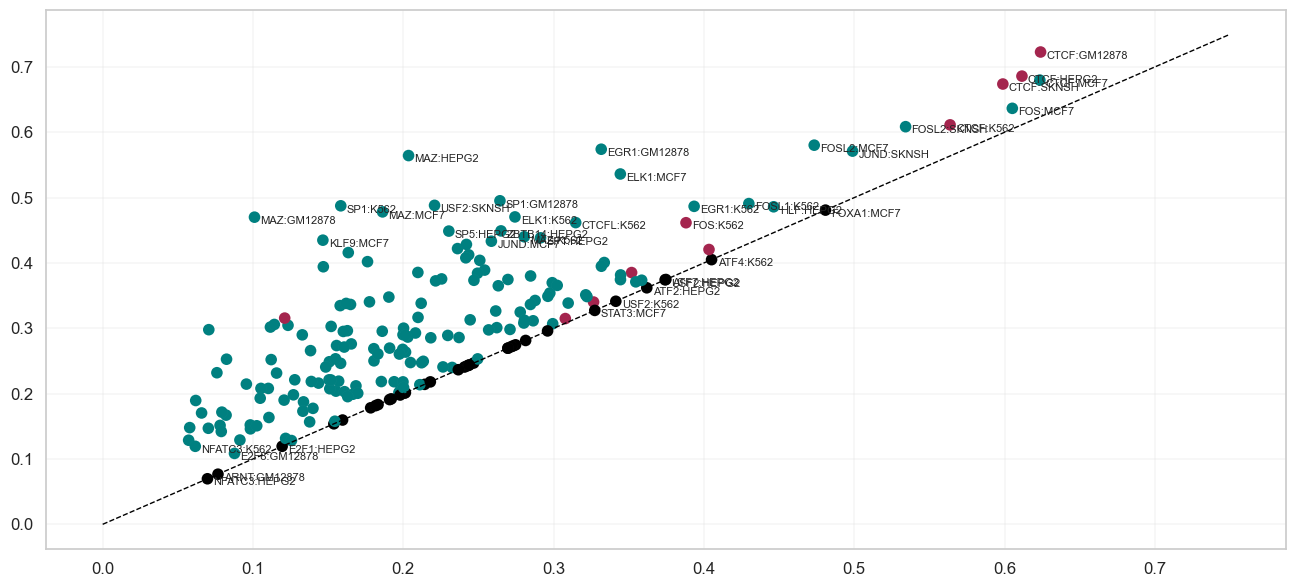

In [21]:
best_case = pd.merge(result[(result.tool == "pwm")][["optimal_score", "label"]], 
                     result.loc[result.groupby("label")["optimal_score"].idxmax()][["optimal_score", "label", "tool"]], 
                     on = "label", how='outer')
best_case = best_case.rename(columns={'optimal_score_x': 'max_pwm_score', 'optimal_score_y': 'max_score'})

sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(16,7))
gs = GridSpec(1, 1, figure=fig, wspace = 0.2, hspace=0.2)

myx = "max_pwm_score"
myy = "max_score"

ax = fig.add_subplot(gs[0])
ax.plot([0, 0.75], [0, 0.75], color='black', linestyle='--', linewidth=1)
to_label = np.concatenate([best_case.sort_values("max_score", ascending=False)[0:30]["label"].values,
                          best_case[best_case["tool"] == "pwm"].sort_values("max_score", ascending=False)[0:7]["label"].values,
                          best_case.sort_values("max_score", ascending=True)[0:5]["label"].values])


sns.scatterplot(data=best_case, x=myx, y=myy, ax=ax, hue="tool", palette=color_scheme_prog, linewidth=0.01, s=70, legend=False)
for i, point in best_case[best_case.label.isin(to_label)].iterrows():
  plt.text(point[myx]+0.004, point[myy]-0.01, point['label'], fontsize =8)

ax.set_title("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
ax.tick_params(axis='both', labelsize=12)

plt.show()

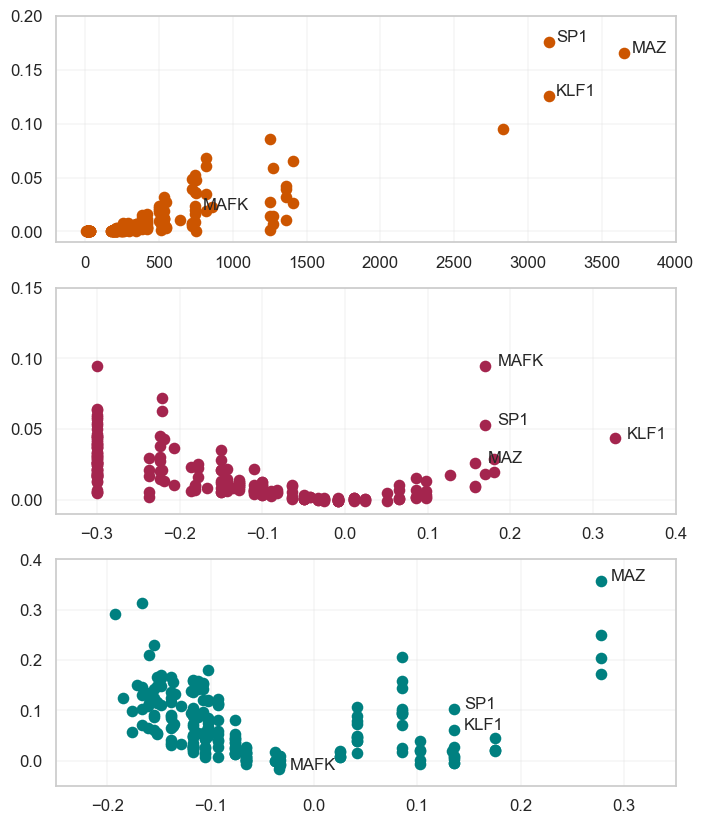

In [23]:
def _applyformat(ax):
    ax.set_title("")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
    ax.tick_params(axis='both', labelsize=12)
    return ax

    
sns.set(font_scale=0.8, style='whitegrid')
fig = plt.figure(figsize=(8,10))
gs = GridSpec(3, 1, figure=fig, wspace = 0.2, hspace=0.2)

tf_to_label = ["SP1:K562", "KLF1:K562", "MAZ:GM12878",  "MAFK:K562"]
#"KLF10:HEPG2",

myx = "threshold_difference"
myy = "score_difference"

col = "#454545"
ax = fig.add_subplot(gs[0])
t = "hint"
sns.scatterplot(data=result[result.tool == t], 
                x=myx, y=myy, s=70, linewidth=0.001,
                ax=ax, 
                #color=col)
                color=color_scheme_prog[t])

for i, point in result[(result.tool == t) & (result.label.isin(tf_to_label))].iterrows():
  plt.text(point[myx]+50, point[myy], point['chipd_tf'], fontsize=12)
ax = _applyformat(ax)
ax.set_xlim(-200, 4000)
ax.set_ylim(-0.01, 0.2)
ax.set_yticks([0, 0.05, 0.1, 0.15, 0.2])


ax = fig.add_subplot(gs[1])
t = "print"
sns.scatterplot(data=result[result.tool == t], 
                x=myx, y=myy, s=70, linewidth=0.001,
                ax=ax, 
                #color=col)
                color=color_scheme_prog[t])

for i, point in result[(result.tool == t) & result.label.isin(tf_to_label)].iterrows():
  plt.text(point[myx]+0.015, point[myy], point['chipd_tf'], fontsize=12)

ax = _applyformat(ax)
ax.set_xlim(-0.35, 0.4)
ax.set_ylim(-0.01, 0.15)
ax.set_yticks([0, 0.05, 0.1, 0.15])

ax = fig.add_subplot(gs[2])
t = "tobias"
sns.scatterplot(data=result[result.tool == t], 
                x=myx, y=myy, s=70, linewidth=0.001,
                ax=ax, 
                #color=col)
                color=color_scheme_prog[t])
for i, point in result[(result.tool == t) & result.label.isin(tf_to_label)].iterrows():
  plt.text(point[myx]+0.01, point[myy], point['chipd_tf'], fontsize=12)
ax = _applyformat(ax)
ax.set_xlim(-0.25, 0.35)
ax.set_ylim(-0.05, 0.4)
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
plt.show()

## 3.2 Try what regions are evaluated on.

In [ ]:
##makes the alternate_performance_calculations.csv files. 

In [28]:
def _format_binary_pivot(df, atac_regions, motifs):
    tmp_pivot = df.pivot_table(index="region_atac", columns="motif", aggfunc='size', fill_value=0)
    tmp_pivot = tmp_pivot.reindex(atac_regions, axis=0, fill_value=0) #only rows matter, not columns. 
    tmp_pivot = tmp_pivot.reindex(motifs, axis=1, fill_value=0)
    tmp_pivot = tmp_pivot.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize
    return tmp_pivot

    
def _get_observed(cl, tool, atac_regions, motifs):
    infile = f"../06_dataquality/{tool}/cleaned/{cl}-cellFilt.bed"
    tmp = pd.read_csv(infile, sep="\t")
    tmp = tmp.loc[tmp["region_atac"].isin(atac_regions) & tmp["motif"].isin(motifs)]
    
    if tool == "hint": tmp["score"] = tmp["tag_count"]
    tmp['rank'] = tmp.groupby('motif')['score'].rank(method='first', ascending=False)
    return tmp


def _calc_individual_scores(df, versus="Footprinting", shuffle=False):
    
    def _safe_divide(numerator, denominator):
        return np.nan if denominator == 0 else round(numerator / denominator, 4)

    if shuffle:
        np.random.seed(42069)
        df[versus] = np.random.permutation(df[versus].values)
        
    chip_pos = df["ChIP"] > 0
    chip_zero = df["ChIP"] == 0
    footprint_pos = df[versus] > 0
    footprint_zero = df[versus] == 0

    tp = np.sum(chip_pos & footprint_pos)
    fp = np.sum(chip_zero & footprint_pos)
    fn = np.sum(chip_pos & footprint_zero)
    tn = np.sum(chip_zero & footprint_zero)

    precision = _safe_divide(tp, tp + fp)
    recall    = _safe_divide(tp, tp + fn)
    f1        = _safe_divide(tp, tp + 0.5 * (fp + fn))
    fpr       = _safe_divide(fp, fp + tn)

    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'total foot': np.sum(footprint_pos),
        'total chip': np.sum(chip_pos),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'tool':versus,
        'shuffled': shuffle
    }


def main(cell_line):
    outfile = f"../11_chip/{cell_line}/alternate_performance_calculations.csv"
    
    #GET TF MATCHES
    motif_to_tf  = pd.read_csv(f"../11_chip/{cell_line}/motif_performance.csv.gz", sep=",")
    motif_to_tf.dropna(inplace=True)
    tf_zipped = list(zip(list(motif_to_tf["ChIPd_TF"]), list(motif_to_tf["BestMotif"])))
    all_motifs = np.unique([j for i,j in tf_zipped])
    all_tfs = np.unique([i for i,j in tf_zipped])
    
    #READ IN EXPECTED DATAFRAME
    tmp = pd.read_csv(f"../11_chip/{cell_line}/chip.mat", sep=",", index_col="region_atac")
    tmp = tmp.loc[:, all_tfs]
    edf = tmp.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize
    atac_regions = edf.index
    
    #READ IN PWM DATAFRAME
    tmp = pd.read_csv(f"../06_dataquality/pwm/mats/{cell_line}-cellFilt.mat", sep=",", index_col="region_atac")
    tmp = tmp.loc[atac_regions, all_motifs]
    cdf = tmp.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize
    
    #GET PEAK COVERAGE
    peak_df = pd.read_csv(f"../06_dataquality/tfbs_universe/PeakCoverage_{cell_line}.csv", index_col=0)
    peak_df = peak_df.loc[atac_regions, ]
    
    #READ IN OBSERVED DFs
    hint = _get_observed(cl=cell_line, tool="hint", atac_regions=atac_regions, motifs=all_motifs)
    tobias = _get_observed(cl=cell_line, tool="tobias", atac_regions=atac_regions, motifs=all_motifs)
    printt = _get_observed(cl=cell_line, tool="print", atac_regions=atac_regions, motifs=all_motifs)
    
    performance_list = []
    jaccard_list = []

    for score_type in ["none", "baseline", 10000, 5000]:
        print(score_type)

        if score_type == "none":
            hdf = _format_binary_pivot(hint.copy(), atac_regions=atac_regions, motifs=all_motifs)
            tdf = _format_binary_pivot(tobias.copy(), atac_regions=atac_regions, motifs=all_motifs)
            pdf = _format_binary_pivot(printt.copy(), atac_regions=atac_regions, motifs=all_motifs)
        elif score_type == "baseline":
            hdf = _format_binary_pivot(hint.copy(), atac_regions=atac_regions, motifs=all_motifs)
            tdf = _format_binary_pivot(tobias.loc[tobias['boolean_score'] == 1].copy(), atac_regions=atac_regions, motifs=all_motifs)
            pdf = _format_binary_pivot(printt.loc[printt['score'] >= 0.3].copy(), atac_regions=atac_regions, motifs=all_motifs)
        else:
            hdf = _format_binary_pivot(hint.loc[hint['rank'] <= score_type].copy(), atac_regions=atac_regions, motifs=all_motifs)
            tdf = _format_binary_pivot(tobias.loc[tobias['rank'] <= score_type].copy(), atac_regions=atac_regions, motifs=all_motifs)
            pdf = _format_binary_pivot(printt.loc[printt['rank'] <= score_type].copy(), atac_regions=atac_regions, motifs=all_motifs)
        
        for tf, motif in tf_zipped:
            print(tf)
            df = pd.DataFrame(
                {'TFBS':    cdf[motif].to_numpy(), 
                 'ChIP':    edf[tf].to_numpy(), 
                 'PeakCov': peak_df[cell_line].to_numpy(), 
                 'HINT':    hdf[motif].to_numpy(),
                 'TOBIAS':  tdf[motif].to_numpy(),
                 'PRINT':   pdf[motif].to_numpy()}
            )
        
            conditions = [
                ("chip_regions", df, False),
                ("chip_PWM_regions", df[df["TFBS"] > 0], False),
                ("chip_peak_regions", df[df["PeakCov"] > 100], False),
                ("chip_regions_shuffled", df, True), 
            ]
        
            for prefix, sub_df, shuffle_status in conditions:
                for t in ["HINT", "TOBIAS", "PRINT"]:
                    tmp = _calc_individual_scores(sub_df.copy(), versus=t, shuffle=shuffle_status)
                    tmp.update({"condition": prefix, "tf": tf, "score": score_type})
                    performance_list.append(tmp)
    
    performance_df = pd.DataFrame(performance_list)
    performance_df.to_csv(outfile, index=False)
    return 

#main(cell_line = "HEPG2")

In [26]:
cl = "HEPG2" # "K562"
performance_df = pd.read_csv(f"../11_chip/{cl}/alternate_performance_calculations.csv.gz", index_col=0)
performance_df["type"] = performance_df["condition"] + ":" + performance_df["score"]

#OPTIONALLY ADD THE OPTIMAL F1 SCORE HERE
tmp = pd.read_csv(f"../11_chip/{cl}/decile_metrics.csv.gz")
tmp['tool'] = tmp['tool'].str.upper()
max_rows = tmp.loc[tmp.groupby(["chipd_tf", "tool"])["f1"].idxmax()]
max_rows["type"] = "optimal_score"
max_rows["tf"] = max_rows.chipd_tf

common = list(set(performance_df.columns) & set(max_rows.columns))
performance_df = pd.concat([performance_df[common], max_rows[common]])
display(performance_df)

,TN,precision,tool,fpr,total chip,shuffled,FN,total foot,recall,type,f1,tf,FP
1231,422702,0.1532,HINT,0.0158,8250,False,7019,8036,0.1492,chip_regions:none,0.1512,ATF2,6805
6012,381268,0.1108,TOBIAS,0.1123,8250,False,2238,54251,0.7287,chip_regions:none,0.1924,ATF2,48239
3990,416079,0.2291,PRINT,0.0313,8250,False,4260,17418,0.4836,chip_regions:none,0.3109,ATF2,13428
1231,161455,0.1533,HINT,0.0404,7343,False,6112,8032,0.1676,chip_PWM_regions:none,0.1601,ATF2,6801
6012,120017,0.1108,TOBIAS,0.2867,7343,False,1331,54251,0.8187,chip_PWM_regions:none,0.1952,ATF2,48239
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2833,388085,0.4647,TOBIAS,0.0364,35012,False,22286,27386,0.3635,optimal_score,0.4079,ZNF384,14660
62,391063,0.2212,HINT,0.0090,43139,False,42129,4565,0.0234,optimal_score,0.0423,ZNF652,3555
1637,384544,0.2656,PRINT,0.0255,43139,False,39495,13718,0.0845,optimal_score,0.1282,ZNF652,10074
1322,332888,0.1589,PWM,0.1564,43139,False,31477,73392,0.2703,optimal_score,0.2002,ZNF652,61730


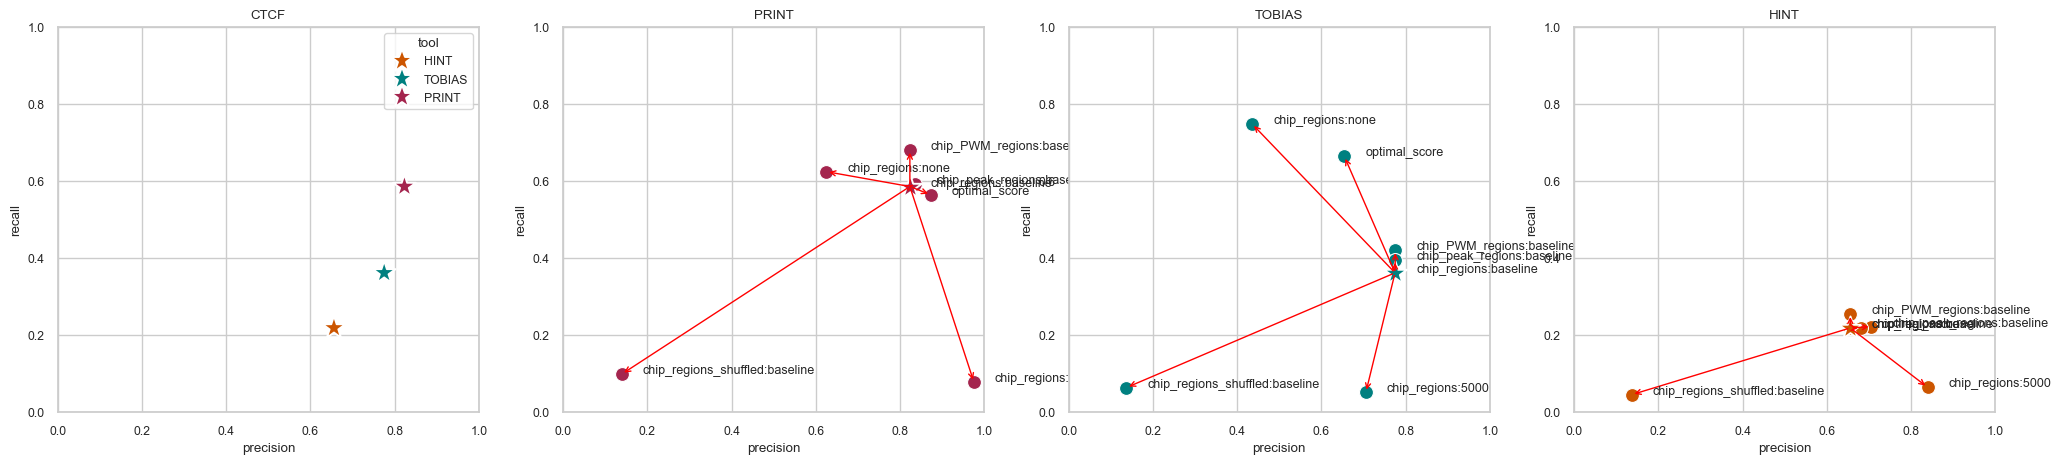

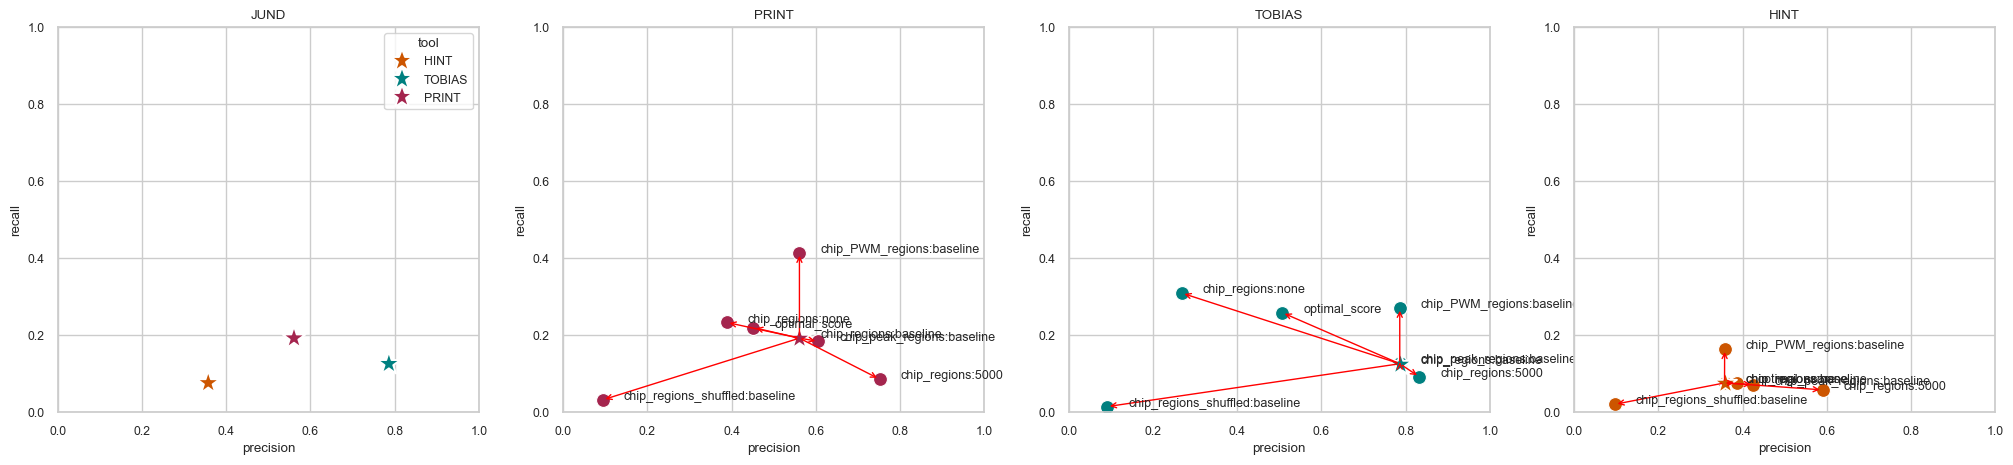

In [27]:
def _complicatedPlotwArrows(df, ax, mycolor="black"):
    myx = "precision"
    myy= "recall"

    baseline = df[df.type == 'chip_regions:baseline'].reset_index()
    x0, y0 = baseline[myx][0], baseline[myy][0]

    sns.scatterplot(df[df.type != 'chip_regions:baseline'], x=myx, y=myy, marker="o", s=100, color=mycolor, ax=ax)
    sns.scatterplot(baseline, x=myx, y=myy, marker="*", s=300, color=mycolor, ax=ax)

    
    for i, row in df.iterrows():
        ax.annotate(
            "", 
            xy=(row[myx], row[myy]), 
            xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='red', lw=1),
            fontsize=9,
            textcoords='data'
        )
        ax.text(row[myx]+0.05, row[myy], row['type'], fontsize=9)

    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    return ax



def wrapper(tf, performance_df):
    color_scheme_prog = {"TOBIAS":"#008080", "HINT":"#CC5500", "PRINT": "#A4254E"}
    
    fig = plt.figure(figsize=(25,5))
    gs = GridSpec(1, 4, figure=fig)#, width_ratios=[1,2])
    
    base_df = performance_df[(performance_df.tf==tf)]
    
    ax1 = fig.add_subplot(gs[0])
    sns.scatterplot(base_df[(base_df.type == 'chip_regions:baseline')], 
                    x = "precision", y="recall", hue="tool", ax=ax1, 
                    marker="*", s=300, palette=color_scheme_prog)
    ax1.set_title(tf)
    #ax1.get_legend().remove()
    ax1.set_ylim(0,1)
    ax1.set_xlim(0,1)

    toshow = ['chip_PWM_regions:baseline',
              'chip_peak_regions:baseline', 
              #'chip_regions:10000', 
              'chip_regions:5000', 
              'chip_regions:baseline',
              'chip_regions:none', 
              'chip_regions_shuffled:baseline',
              'optimal_score']
    
    ax = fig.add_subplot(gs[1])
    t = "PRINT"
    ax = _complicatedPlotwArrows(base_df[(base_df.tool == t) & (base_df.type.isin(toshow))],
                                 ax, color_scheme_prog[t])
    ax.set_title(t)
    
    ax = fig.add_subplot(gs[2])
    t = "TOBIAS"
    ax = _complicatedPlotwArrows(base_df[(base_df.tool == t) & (base_df.type.isin(toshow))],
                                 ax, color_scheme_prog[t])
    ax.set_title(t)
    
    ax = fig.add_subplot(gs[3])
    t = "HINT"
    ax = _complicatedPlotwArrows(base_df[(base_df.tool == t) & (base_df.type.isin(toshow))],
                                 ax, color_scheme_prog[t])
    ax.set_title(t)
    
    plt.show()

wrapper("CTCF", performance_df)
wrapper("JUND", performance_df)

# 4. Given above, calculate FT performance based on chip <a class="anchor" id="four-bullet"></a>
- but do so in a much more paired down way for computational efficiency.

In [3]:
def _calc_scores(df, shuffle=False):
    def _safe_divide(numerator, denominator):
        return np.nan if denominator == 0 else round(numerator / denominator, 4)

    if shuffle:
        np.random.seed(42069)
        df["Footprinting"] = np.random.permutation(df["Footprinting"].values)
        
    chip_pos = df["ChIP"] > 0
    chip_zero = df["ChIP"] == 0
    footprint_pos = df["Footprinting"] > 0
    footprint_zero = df["Footprinting"] == 0

    tp = np.sum(chip_pos & footprint_pos)
    fp = np.sum(chip_zero & footprint_pos)
    fn = np.sum(chip_pos & footprint_zero)
    tn = np.sum(chip_zero & footprint_zero)

    precision = _safe_divide(tp, tp + fp)
    recall    = _safe_divide(tp, tp + fn)
    f1        = _safe_divide(tp, tp + 0.5 * (fp + fn))
    fpr       = _safe_divide(fp, fp + tn)

    return {
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'total foot': np.sum(footprint_pos),
        'total chip': np.sum(chip_pos),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr,
        'shuffled': shuffle
    }



def _process_chunk(args):
    try:
        f_foot, tool, tf_zipped, edf = args
        name = re.sub('.mat', '', os.path.basename(f_foot), count=1)
        joint = []

        #READ IN OBSERVED DATAFRAME
        df_observed = pd.read_csv(f_foot, sep=",", index_col=0)
        df_observed = df_observed.reindex(edf.index)
        odf = df_observed.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0))

        for tf, motif in tf_zipped:
            local_df = pd.DataFrame({'ChIP': edf[tf].to_numpy(), 'Footprinting': odf[motif].to_numpy()})
        
            for shuff in [False, True]:
                scores = _calc_scores(local_df.copy(), shuff)
                scores.update({"motif": motif, "chipd_tf": tf, "file": name, "tool": tool})
                joint.append(scores)
        
        return joint

    except Exception as e:
        print(f"Error processing {f_foot}{tool}: {e}")
        return


def main(cell_line):
    from multiprocessing import Pool
    import random

    tasks = []
    
    #GET TF MATCHES
    motif_to_tf  = pd.read_csv(f"../11_chip/{cell_line}/motif_performance.csv.gz", sep=",")
    motif_to_tf.dropna(inplace=True)
    motif_to_tf = motif_to_tf.sort_values("ChIPd_TF")
    tf_zipped = list(zip(list(motif_to_tf["ChIPd_TF"]), list(motif_to_tf["BestMotif"])))
    
    #READ IN EXPECTED DATAFRAME (chip mat)
    df_expected = pd.read_csv(f"../11_chip/{cell_line}/chip.mat.gz", sep=",", index_col="region_atac")
    edf = df_expected.apply(lambda x: x.map(lambda y: 1 if y != 0 else 0)) #binarize

    #SET-UP IN OBSERVED FILES
    for tool in ["hint", "tobias", "print", "pwm"]:
    #for tool in ["print"]:
        if tool == "tobias":
            data_dir = f"../06_dataquality/tobias/mats/bound_threshold/" 
        elif tool == "print":
            data_dir = f"../06_dataquality/print/mats/thresh_03/"
        else:
            data_dir = f"../06_dataquality/{tool}/mats/" 
        files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".mat") and cell_line in f]
        tasks.extend([(f, tool, tf_zipped, edf) for f in files])
    
    with Pool(processes=25) as pool: 
        all_results = pool.map(_process_chunk, tasks)

    flat_joint = [item for sublist in all_results for item in sublist]
    joint_df = pd.DataFrame(flat_joint)
    joint_df.to_csv(f"../11_chip/{cell_line}/downsampling_metrics.csv", index=False)
    
#main("GM12878")

# 5. How does this relate to ATAC signal? <a class="anchor" id="fifth-bullet"></a>

In [55]:
def _getTotals(f1):
    cmd = f"awk '{{sum += $3 - $2}} END {{print sum}}' {f1}"
    all_bp = ! {cmd}
    all_regions = ! cat {f1} | wc -l
    return int(all_bp[0]), int(all_regions[0])


def _getInfo(input_file, chip_bed, N_bp, N_regions):
    f2 = "tmp_foot.bed"
    ! awk '{{print $$1,$$2,$$3}}' {input_file} | tr " " "\t" | sort -k1,1 -k2,2n > {f2}
    
    cmd1 = f"bedtools intersect -a {chip_bed} -b {f2} -wa -u | bedtools sort | bedtools merge | awk '{{sum += $3 - $2}} END {{print sum}}'"
    cov_bp = ! {cmd1}
    cov_bp = int(cov_bp[0])
    
    cmd2 = f"bedtools intersect -a {chip_bed} -b {f2} -F 0.5 -wa -sorted -u | wc -l"
    cov_regions = ! {cmd2}
    cov_regions = int(cov_regions[0])
    
    return [cov_bp, (cov_bp/N_bp)*100, cov_regions, (cov_regions/N_regions)*100]    
    

def main(cell_line, chip_file, conds = ["02_cells"]):
    outfile = f"../11_chip/{cell_line}/downsampling_atac_peak_overlap.csv.gz"
    
    ##### Get the cell lines motif files to shorten comp time. 
    motif_to_tf  = pd.read_csv(f"../11_chip/{cell_line}/motif_performance.csv.gz", sep=",")
    motif_to_tf = motif_to_tf.dropna()
    
    output_list = list()
    
    for tf in [f"{i}:"for i in motif_to_tf.ChIPd_TF]: #add a colon here so that CTCF cant also match CTCFL
        print(tf)
        
        ##### For this TF, get the total CHIP numbers. 
        ! grep {tf} {chip_file} | awk '{{print $$1, $$2, $$3}}' | tr ' ' '\t' | sort -k1,1 -k2,2n > tmp_chip.bed
        N_bp, N_regions = _getTotals("tmp_chip.bed")
        #print(f"For {tf} there are {N_bp} total basepairs and {N_regions} total regions")
    
        ##### Add the baseline sample 
        input_file=f"../03_peakcalls/{cell_line}_filt_500bp.exclusion.bed.gz"
        output_list.append(_getInfo(input_file, "tmp_chip.bed", N_bp, N_regions) + [tf, cell_line, "NA", "baseline", np.nan])
        
        for dt in conds:
            dd = f"../05_footprinting/{dt}/macs3/"
            
            ##### Add all downsampling conditions. 
            files = [os.path.join(dd, f) for f in os.listdir(dd) if f.endswith("_filt_500bp.exclusion.bed") and cell_line in f]
            for input_file in files:
                name = re.sub('_filt_500bp.exclusion.bed', '', os.path.basename(input_file), count=1)
                output_list.append(_getInfo(input_file, "tmp_chip.bed", N_bp, N_regions) + [tf, cell_line, dt[3:], name, name.split("_")[1][1:]])
    
    df = pd.DataFrame(output_list, 
                      columns = ["bp_overlap",  "bp_percent", "region_overlap", "region_percent", 
                                 "tf", "cell_line", "sampling_type", "file", "value"])
    df.to_csv(outfile, index=False)
    return


# main(cell_line="K562", 
#      chip_file="/pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_K-562_nr_macs2_hg38_v1_0.bed", 
#      conds = ["02_cells", "03_reads", "04_frip"])

# main(cell_line="HEPG2", 
#      chip_file="/pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_Hep-G2_nr_macs2_hg38_v1_0.bed", 
#      conds = ["02_cells", "03_reads", "04_frip"])

# main(cell_line="SKNSH", 
#      chip_file="/pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_SK-N-SH_nr_macs2_hg38_v1_0.bed", 
#      conds = ["02_cells", "03_reads", "04_frip"])

# main(cell_line="MCF7", 
#      chip_file="/pollard/data/projects/aseveritt/footprint_programs/remap22/remap2022_MCF-7_nr_macs2_hg38_v1_0.bed", 
#      conds = ["02_cells", "03_reads", "04_frip"])

In [30]:
atac_regions = pd.concat([
    pd.read_csv(f"../11_chip/K562/downsampling_atac_peak_overlap.csv.gz"),
    pd.read_csv(f"../11_chip/HEPG2/downsampling_atac_peak_overlap.csv.gz"),
    pd.read_csv(f"../11_chip/SKNSH/downsampling_atac_peak_overlap.csv.gz")
])
#display(atac_regions)

all_metrics = pd.read_csv("../04_downsampling/sampling_stats.csv", sep=",", index_col=0)
all_metrics = all_metrics[all_metrics["sampling_type"] == "baseline"]

res = [
    atac_regions[atac_regions['file'] != "baseline"]
]
for cl in ['HEPG2', 'K562', 'SKNSH']:
    sub = atac_regions[(atac_regions['file'] == "baseline") & (atac_regions["cell_line"] == cl)]
    for st, col in [("cells", "Ncells"), ("reads", "Nreadpairs"), ("frip", "FRIP")]:
        sub2 = sub.copy()
        sub2["sampling_type"] = st
        sub2["value"] = all_metrics.loc[cl][col]
        res.append(sub2)

df = pd.concat(res)
df.tf = [i[:-1] for i in df.tf]
df.loc[(df.sampling_type == "frip") & (df.file !="baseline"), "value"] = df.loc[(df.sampling_type == "frip") & (df.file !="baseline")]["value"]/10
df.loc[(df.sampling_type == "frip") & (df.value ==2.5), "value"] = 0.25
df.loc[(df.sampling_type == "frip") & (df.value ==3.5), "value"] = 0.35
df.loc[(df.sampling_type == "frip") & (df.value ==0.5), "value"] = 0.05
display(df)

,bp_overlap,bp_percent,region_overlap,region_percent,tf,cell_line,sampling_type,file,value
1,4488887,27.411288,7664,14.807087,ATF2,K562,cells,K562_c2500_s3,2500.000
2,5898594,36.019632,9988,19.297127,ATF2,K562,cells,K562_c40000_s7,40000.000
3,3860566,23.574460,6480,12.519562,ATF2,K562,cells,K562_c1000_s7,1000.000
4,5640749,34.445107,9626,18.597732,ATF2,K562,cells,K562_c20000_s85,20000.000
5,5210167,31.815768,8953,17.297475,ATF2,K562,cells,K562_c10000_s76,10000.000
...,...,...,...,...,...,...,...,...,...
630,14511097,85.941323,24042,40.603256,NFIC,SKNSH,frip,baseline,0.285
700,4415708,94.702873,6760,37.605696,RXRA,SKNSH,frip,baseline,0.285
770,8818097,89.353475,17849,57.919330,TEAD4,SKNSH,frip,baseline,0.285
840,7293421,68.913546,4985,8.847280,USF1,SKNSH,frip,baseline,0.285


In [31]:
mean_df = df.groupby(["tf", "value", "cell_line", "sampling_type"])[["region_percent"]].apply(lambda col: col.mean())
std_df  = df.groupby(["tf", "value", "cell_line", "sampling_type"])[["region_percent"]].apply(lambda col: col.std())
byGroup_df = pd.concat([mean_df.add_suffix('_mean'), std_df.add_suffix('_sd')], axis=1)
byGroup_df.reset_index(inplace=True)
display(byGroup_df)

,tf,value,cell_line,sampling_type,region_percent_mean,region_percent_sd
0,ATF2,5.000000e-02,HEPG2,frip,7.068721,0.018599
1,ATF2,5.000000e-02,K562,frip,15.482010,0.024002
2,ATF2,1.000000e-01,HEPG2,frip,7.310029,0.012931
3,ATF2,1.000000e-01,K562,frip,17.110712,0.010641
4,ATF2,2.000000e-01,HEPG2,frip,7.697642,0.007173
...,...,...,...,...,...,...
3483,ZNF652,1.000000e+07,HEPG2,reads,25.994699,0.099859
3484,ZNF652,5.000000e+07,HEPG2,reads,28.143839,0.022996
3485,ZNF652,1.000000e+08,HEPG2,reads,28.776691,0.016417
3486,ZNF652,5.000000e+08,HEPG2,reads,29.387317,0.008390


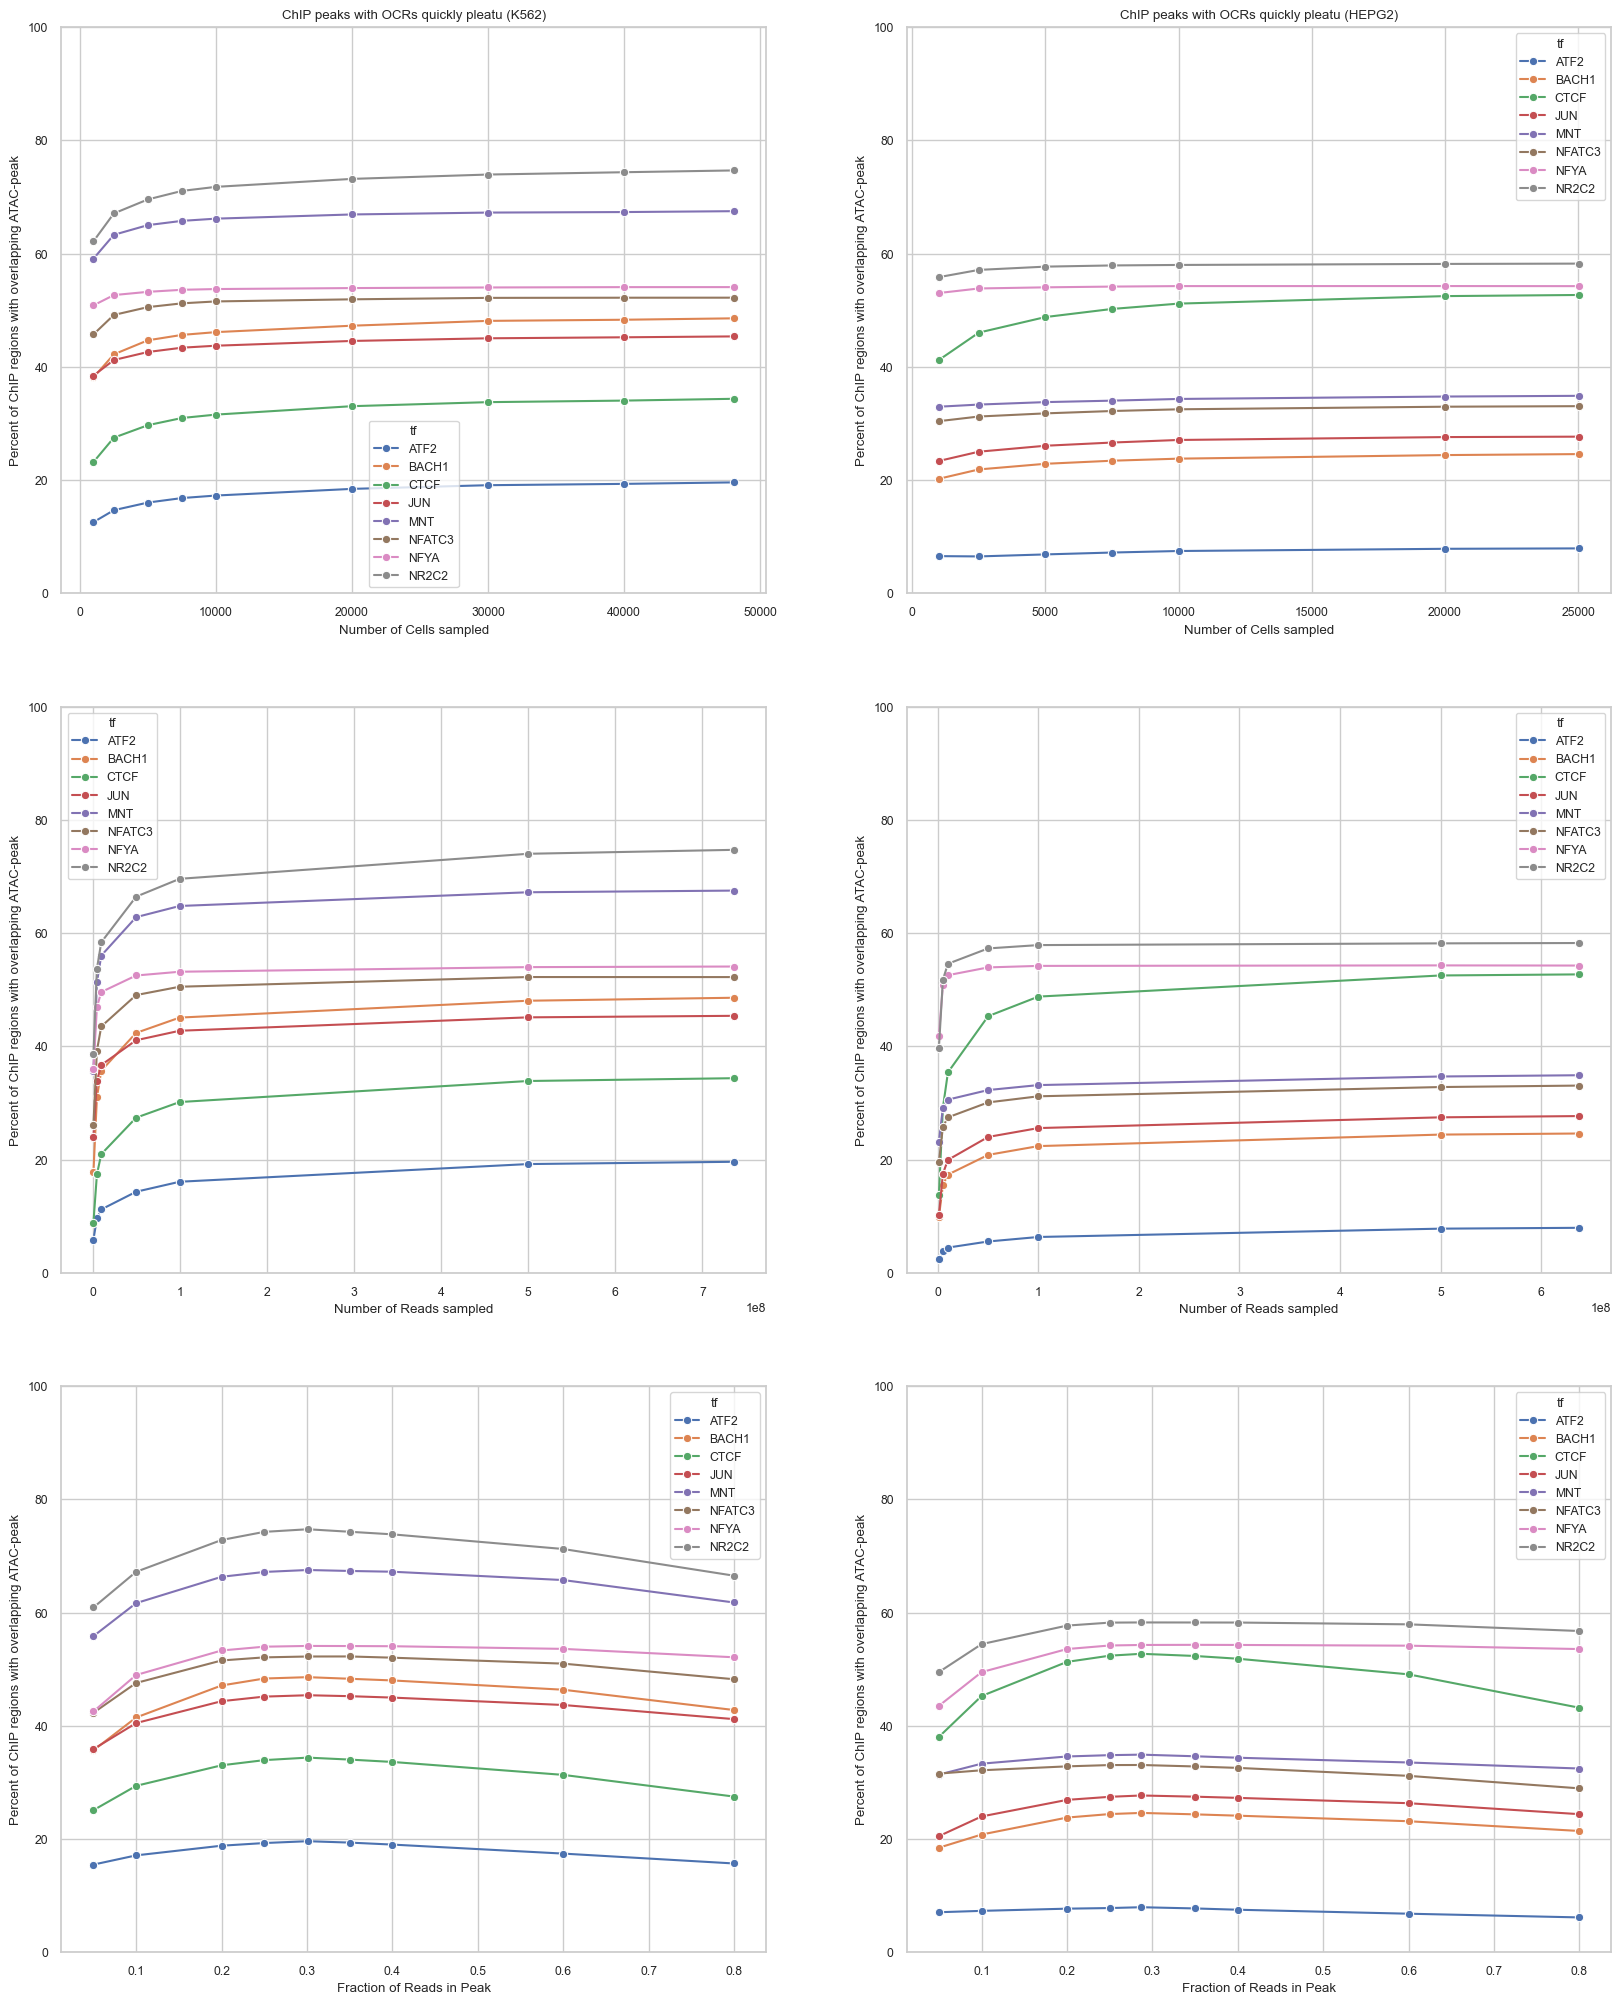

In [32]:
fig = plt.figure(figsize=(20,25))
gs = GridSpec(3, 2, figure=fig)#, width_ratios=[1,2])

#set(byGroup_df[byGroup_df.cell_line == "K562"]["tf"]) & set(byGroup_df[byGroup_df.cell_line == "HEPG2"]["tf"])
#tfs = ['ATF2', 'BACH1', 'CTCF', 'FOS', 'GATA2', 'JUND', 'MAX', 'SP1', 'USF1', 'ZNF384']
tfs = ["NR2C2", "NFYA", "BACH1", "JUN", "CTCF", "ATF2",  "NFATC3", "MNT"]
sub = byGroup_df[(byGroup_df.tf.isin(tfs))]


ax1 = fig.add_subplot(gs[0])
sns.lineplot(sub[(sub.sampling_type=="cells") & (sub.cell_line == "K562")], x="value", y="region_percent_mean", marker='o', hue="tf", ax=ax1, errorbar=None)
ax1.set_xlabel("Number of Cells sampled")
ax1.set_ylabel("Percent of ChIP regions with overlapping ATAC-peak")
ax1.set_title("ChIP peaks with OCRs quickly pleatu (K562)")
ax1.set_ylim(0,100)

ax1 = fig.add_subplot(gs[1])
sns.lineplot(sub[(sub.sampling_type=="cells") & (sub.cell_line == "HEPG2")], x="value", y="region_percent_mean", marker='o', hue="tf", ax=ax1, errorbar=None)
ax1.set_xlabel("Number of Cells sampled")
ax1.set_ylabel("Percent of ChIP regions with overlapping ATAC-peak")
ax1.set_title("ChIP peaks with OCRs quickly pleatu (HEPG2)")
ax1.set_ylim(0,100)

ax1 = fig.add_subplot(gs[2])
sns.lineplot(sub[(sub.sampling_type=="reads") & (sub.cell_line == "K562")], x="value", y="region_percent_mean", marker='o', hue="tf", ax=ax1, errorbar=None)
ax1.set_xlabel("Number of Reads sampled")
ax1.set_ylabel("Percent of ChIP regions with overlapping ATAC-peak")
ax1.set_ylim(0,100)

ax1 = fig.add_subplot(gs[3])
sns.lineplot(sub[(sub.sampling_type=="reads") & (sub.cell_line == "HEPG2")], x="value", y="region_percent_mean", marker='o', hue="tf", ax=ax1, errorbar=None)
ax1.set_xlabel("Number of Reads sampled")
ax1.set_ylabel("Percent of ChIP regions with overlapping ATAC-peak")
ax1.set_ylim(0,100)

ax1 = fig.add_subplot(gs[4])
sns.lineplot(sub[(sub.sampling_type=="frip") & (sub.cell_line == "K562")], x="value", y="region_percent_mean", marker='o', hue="tf", ax=ax1, errorbar=None)
ax1.set_xlabel("Fraction of Reads in Peak")
ax1.set_ylabel("Percent of ChIP regions with overlapping ATAC-peak")
ax1.set_ylim(0,100)

ax1 = fig.add_subplot(gs[5])
sns.lineplot(sub[(sub.sampling_type=="frip") & (sub.cell_line == "HEPG2")], x="value", y="region_percent_mean", marker='o', hue="tf", ax=ax1, errorbar=None)
ax1.set_xlabel("Fraction of Reads in Peak")
ax1.set_ylabel("Percent of ChIP regions with overlapping ATAC-peak")
ax1.set_ylim(0,100)


plt.show()

## What features are actually the most important in predicting F1 score?
    1. Gather all the needed info
    2. Fit w/ TFs tools and cell lines together -- these should rank higher than downsampling condition. 
    3. Fit separately for each TF-cell line pair. 

In [33]:
import matplotlib.colors as mcolors

def _radar_plot(tool, df, col="abs_coef_mean"):   
    sns.set_style("white")
    values = df[df.tool==tool][col]
    labels = df[df.tool==tool]['group']
    
    num_bars = len(values)
    angles = np.linspace(0, 2 * np.pi, num_bars, endpoint=False)
    width = 2 * np.pi / num_bars
    
    cmap = plt.cm.tab20c
    #cmap = plt.cm.Dark2
    colors = [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, len(labels))]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    bars = ax.bar(angles, values, width=width, 
                  color=colors,
                  alpha=0.7, linewidth=0.4)

    ax.set_title(tool)    
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.grid(which='major', color='#DDDDDD', linewidth=0.4)
    plt.show()

In [34]:
##### GET CONDITION PROPERTIES ##### 
all_metrics = pd.read_csv("../04_downsampling/sampling_stats.csv", sep=",", index_col=0)
all_metrics = all_metrics[["FRIP", "Ncells", "Nnonpeakpairs","Npeakpairs","Nreadpairs","sampling_type", "value"]]
all_metrics["file"] = all_metrics.index
#display(all_metrics)



##### GET ATAC-TO-CHIP OVERLAP ##### 
atac_regions = pd.concat([
    pd.read_csv(f"../11_chip/K562/downsampling_atac_peak_overlap.csv.gz"),
    pd.read_csv(f"../11_chip/HEPG2/downsampling_atac_peak_overlap.csv.gz"),
    pd.read_csv(f"../11_chip/SKNSH/downsampling_atac_peak_overlap.csv.gz"),
    pd.read_csv(f"../11_chip/MCF7/downsampling_atac_peak_overlap.csv.gz")
])
atac_regions.loc[atac_regions.file == "baseline", "file"] = atac_regions.loc[atac_regions.file == "baseline", "cell_line"] 
atac_regions = atac_regions[['bp_overlap', 'bp_percent', 'region_overlap', 'region_percent', 'tf', 'file', "cell_line"]]
#display(atac_regions)


##### GET F1 SCORE USING CHIP AS BACKGROUND #####
down_df = pd.concat([pd.read_csv(f"../11_chip/HEPG2/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/K562/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/SKNSH/downsampling_metrics.csv.gz", sep=","),
                pd.read_csv(f"../11_chip/MCF7/downsampling_metrics.csv.gz", sep=",")]
)
down_df['file'] = down_df['file'].str.replace("-cellFilt", '', regex=False)
down_df = down_df[down_df["shuffled"] == False]
down_df =  down_df[['total foot', 'total chip', 'precision', 'recall', 'f1', 'fpr', 'shuffled', 'motif', 'chipd_tf', 'file', 'tool']]
pwm_df = down_df[down_df.tool == "pwm"]
down_df = down_df[down_df.tool != "pwm"]
#display(down_df)

##### GET MOTIF SCANNING RESULTS #####
pwm_df = pwm_df.add_suffix('_pwm')
pwm_df = pwm_df[['precision_pwm', 'recall_pwm', 'f1_pwm', 'fpr_pwm', 'motif_pwm', 'chipd_tf_pwm', 'file_pwm']]

#display(pwm_df)

In [35]:
##### MERGE IT ALL #####

df1=all_metrics.merge(atac_regions, on="file", how="right")
df1["chipd_tf"] = [i[:-1] for i in df1.tf]

df2 = df1.merge(down_df, on=["chipd_tf", "file"], how="outer")

df3 = df2.merge(pwm_df, left_on=["motif", "chipd_tf", "cell_line"], right_on=["motif_pwm", "chipd_tf_pwm", "file_pwm"],  how="outer")

joined_df = df3[["file", 'sampling_type', "cell_line", 'tool', 'chipd_tf', 'motif', 
                 'FRIP', 'Ncells', 'Nnonpeakpairs', 'Npeakpairs', 'Nreadpairs', 
                 'bp_overlap', 'bp_percent','region_overlap', 'region_percent',
                 'precision_pwm', 'recall_pwm', 'f1_pwm',
                 'total foot', 'total chip', 'precision', 'recall', 'f1', 'fpr']]

display(joined_df)

,file,sampling_type,cell_line,tool,chipd_tf,motif,FRIP,Ncells,Nnonpeakpairs,Npeakpairs,...,region_percent,precision_pwm,recall_pwm,f1_pwm,total foot,total chip,precision,recall,f1,fpr
0,MCF7,baseline,MCF7,hint,ARNT,ARNT::HIF1A_MA0259.1,0.286,32303,411746319,164654162,...,63.822285,0.1589,0.7037,0.2592,1741,34282,0.2924,0.0148,0.0283,0.0036
1,MCF7,baseline,MCF7,tobias,ARNT,ARNT::HIF1A_MA0259.1,0.286,32303,411746319,164654162,...,63.822285,0.1589,0.7037,0.2592,2389,34282,0.6831,0.0476,0.0890,0.0022
2,MCF7,baseline,MCF7,print,ARNT,ARNT::HIF1A_MA0259.1,0.286,32303,411746319,164654162,...,63.822285,0.1589,0.7037,0.2592,1459,34282,0.4544,0.0193,0.0371,0.0023
3,MCF7_c10000_s17,cells,MCF7,hint,ARNT,ARNT::HIF1A_MA0259.1,0.286,10000,128240348,51419725,...,62.747864,0.1589,0.7037,0.2592,1818,34282,0.3185,0.0169,0.0321,0.0036
4,MCF7_c10000_s17,cells,MCF7,tobias,ARNT,ARNT::HIF1A_MA0259.1,0.286,10000,128240348,51419725,...,62.747864,0.1589,0.7037,0.2592,2059,34282,0.7086,0.0426,0.0803,0.0017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34364,HEPG2_r5e8_s59,reads,HEPG2,tobias,ZNF652,ZNF652_MA1657.1,0.288,25043,355848042,144151958,...,29.388429,0.1106,0.6021,0.1869,3587,43139,0.6041,0.0502,0.0928,0.0036
34365,HEPG2_r5e8_s59,reads,HEPG2,print,ZNF652,ZNF652_MA1657.1,0.288,25043,355848042,144151958,...,29.388429,0.1106,0.6021,0.1869,4092,43139,0.4648,0.0441,0.0805,0.0055
34366,HEPG2_r5e8_s9,reads,HEPG2,hint,ZNF652,ZNF652_MA1657.1,0.288,25043,355847293,144152707,...,29.395096,0.1106,0.6021,0.1869,4607,43139,0.2242,0.0239,0.0433,0.0091
34367,HEPG2_r5e8_s9,reads,HEPG2,tobias,ZNF652,ZNF652_MA1657.1,0.288,25043,355847293,144152707,...,29.395096,0.1106,0.6021,0.1869,3582,43139,0.6039,0.0501,0.0926,0.0036


In [37]:
#Check the values are unique
group_sizes = joined_df.groupby(["file", "chipd_tf", "motif", "tool"]).size()
any_group_larger_than_one = (group_sizes > 1).any()
print(any_group_larger_than_one)

#Find and remove NAn values. 
#print("DROPPING THE FOLLOWING COLUMNS:")
#display(joined_df[joined_df.isnull().any(axis=1)])
joined_df = joined_df.dropna()


False


In [142]:
# all possible:
# joined_df.columns 
# categorical = ['file', 'sampling_type', 'cell_line',  'chipd_tf', 'motif', 'tool']
# numerical = ['FRIP', 'Ncells', 'Nnonpeakpairs', 'Npeakpairs', 'Nreadpairs', 
#              'bp_overlap', 'bp_percent', 'region_overlap', 'region_percent', 'precision_pwm',
#              'recall_pwm', 'f1_pwm', 'total foot', 'total chip', 'precision',
#              'recall', 'f1', 'fpr']

In [38]:
print(joined_df.shape)
tmp = joined_df[joined_df.sampling_type.isin(["reads", "baseline"])].copy()
tmp['value_delta'] = (
    tmp.sort_values(['Nreadpairs'], ascending=False)  
      .groupby(['cell_line', 'tool', 'chipd_tf'])['f1']         
      .diff()                                                                      
)
tmp["delta_st"] = "reads" #have to do this for the baseline samples when they duplicate. 

tmp1 = joined_df[joined_df.sampling_type.isin(["frip", "baseline"])].copy()
tmp1['value_delta'] = (
    tmp1.sort_values(['FRIP'], ascending=False)  
      .groupby(['cell_line', 'tool', 'chipd_tf'])['f1']         
      .diff()                                                                      
)
tmp1["delta_st"] = "frip" #have to do this for the baseline samples when they duplicate. 


tmp2 = joined_df[joined_df.sampling_type.isin(["cells", "baseline"])].copy()
tmp2['value_delta'] = (
    tmp2.sort_values(['Ncells'], ascending=False)  
      .groupby(['cell_line', 'tool', 'chipd_tf'])['f1']         
      .diff()                                                                      
)
tmp2["delta_st"] = "cells" #have to do this for the baseline samples when they duplicate. 

joined_df_delta = pd.concat([tmp, tmp1, tmp2])
print(joined_df_delta.shape)
joined_df_delta = joined_df_delta.dropna()

(34367, 24)
(35447, 26)


### Univariate

In [39]:
color_scheme_prog = {"TOBIAS":"#008080", "HINT":"#CC5500", "PRINT": "#A4254E"}

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

results = []

for i, tool in enumerate(["hint", "tobias", "print"]):
    #subset = joined_df[joined_df["tool"] == tool]
    subset = joined_df_delta[joined_df_delta["tool"] == tool]
    for val in ['FRIP', 'Ncells', 'Npeakpairs', 'Nreadpairs', 'bp_percent', 'f1_pwm']:
        X = subset[[val]].values
        #Y = subset['precision'].values
        Y = subset['value_delta'].values

        model = LinearRegression().fit(X, Y)
        Y_pred = model.predict(X)

        r2 = r2_score(Y, Y_pred)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred))
        results.append([tool, val, r2, rmse])
    
# Show results
df_results = pd.DataFrame(results, columns=['tool', 'group', 'R^2', 'RMSE'])
display(df_results.sort_values("R^2", ascending=False)[:15])

,tool,group,R^2,RMSE
14,print,Npeakpairs,0.069364,0.018876
15,print,Nreadpairs,0.063274,0.018938
4,hint,bp_percent,0.062353,0.006040
16,print,bp_percent,0.024413,0.019327
5,hint,f1_pwm,0.014789,0.006191
3,hint,Nreadpairs,0.014280,0.006193
2,hint,Npeakpairs,0.012865,0.006197
17,print,f1_pwm,0.010689,0.019462
13,print,Ncells,0.009896,0.019470
10,tobias,bp_percent,0.007991,0.023075


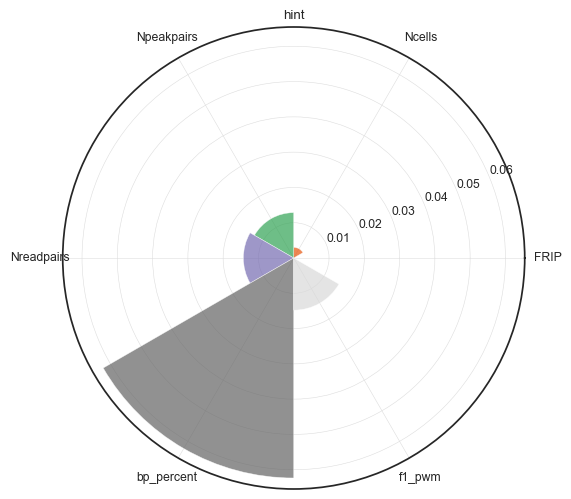

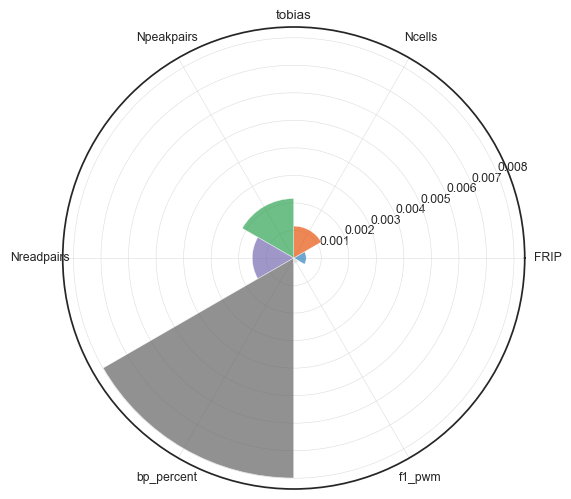

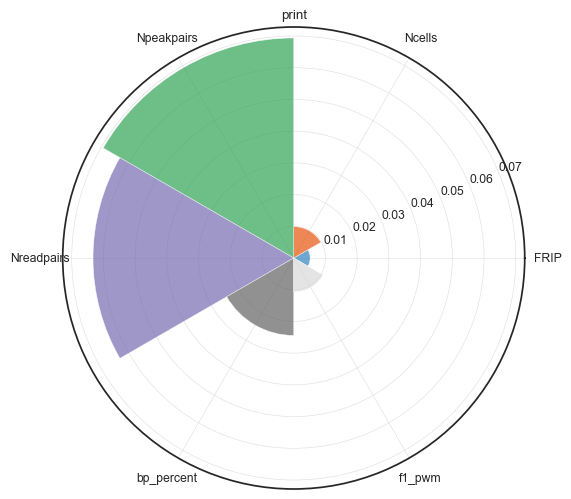

In [40]:
_radar_plot("hint", df_results, col="R^2")
_radar_plot("tobias", df_results, col="R^2")
_radar_plot("print", df_results, col="R^2")

### Multi-varivariate

In [41]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

#First, lets do this by TF to see if we can pick up differences. 

# target = "f1"
# grouped = joined_df.groupby(["chipd_tf", "tool"]) 

target = "value_delta"
grouped = joined_df_delta.groupby(["chipd_tf", "tool"]) 

categorical = ['cell_line']
numerical = ['FRIP', 'Ncells', 'Npeakpairs', 'Nreadpairs', 'bp_percent', 'f1_pwm']
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(drop="first"), categorical),
])

model = make_pipeline(preprocessor, RidgeCV(cv=10, alphas=[0.5])) #alpha choice doesnt change the interpretation

res = []
for group_key, group_df in grouped:
    X = group_df[numerical + categorical]
    y = group_df[target]
    model.fit(X, y)

    ridge = model.named_steps["ridgecv"]
    feature_names = (
        numerical +
        list(model.named_steps["columntransformer"]
             .named_transformers_["cat"]
             .get_feature_names_out(categorical))
    )

    coefs = ridge.coef_

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    res.append({
        "group": group_key,
        "coefficients": dict(zip(feature_names, coefs)),
        "r2": r2
    })

print("done")

done


In [42]:
all_coefs = []

for result in res:
    for feature, coef in result["coefficients"].items():
        all_coefs.append({
            "tf": result["group"][0],
             "tool": result["group"][1],
            "feature": feature,
            "coef": coef,
            "abs_coef": np.abs(coef),
            "r2": result["r2"]
        })


coef_df = pd.DataFrame(all_coefs)
coef_df['group'] = coef_df['feature'].apply(
    lambda x: 'tool' if x.startswith('tool_') else (
              'cell_line' if x.startswith('cell_line_') else x
))

display(coef_df)

,tf,tool,feature,coef,abs_coef,r2,group
0,ARNT,hint,FRIP,0.000215,0.000215,0.110041,FRIP
1,ARNT,hint,Ncells,0.000119,0.000119,0.110041,Ncells
2,ARNT,hint,Npeakpairs,-0.000348,0.000348,0.110041,Npeakpairs
3,ARNT,hint,Nreadpairs,0.000024,0.000024,0.110041,Nreadpairs
4,ARNT,hint,bp_percent,0.000736,0.000736,0.110041,bp_percent
...,...,...,...,...,...,...,...
2335,ZNF652,tobias,Ncells,0.001734,0.001734,0.138400,Ncells
2336,ZNF652,tobias,Npeakpairs,-0.012101,0.012101,0.138400,Npeakpairs
2337,ZNF652,tobias,Nreadpairs,0.003759,0.003759,0.138400,Nreadpairs
2338,ZNF652,tobias,bp_percent,0.009101,0.009101,0.138400,bp_percent


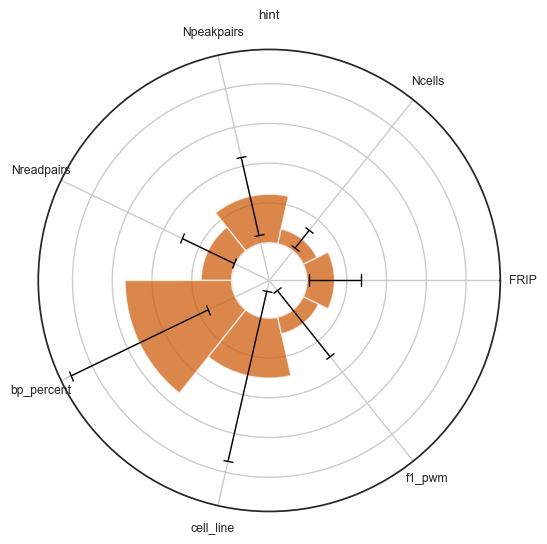

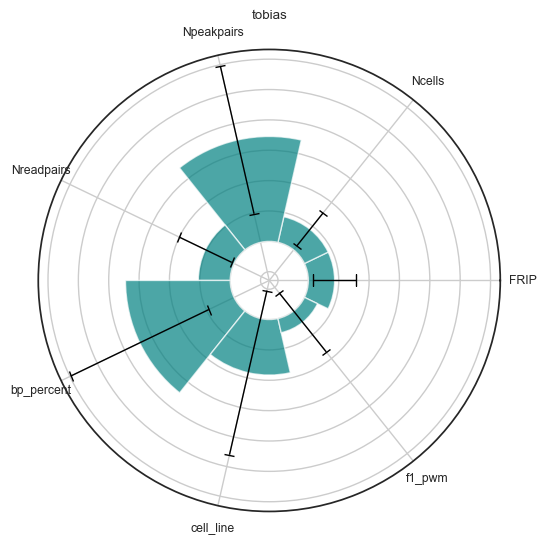

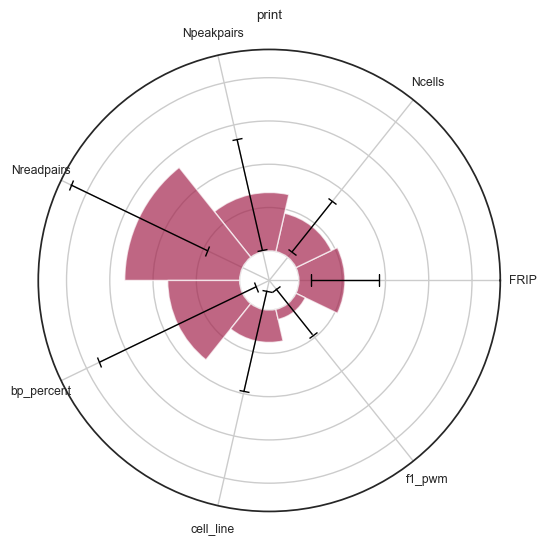

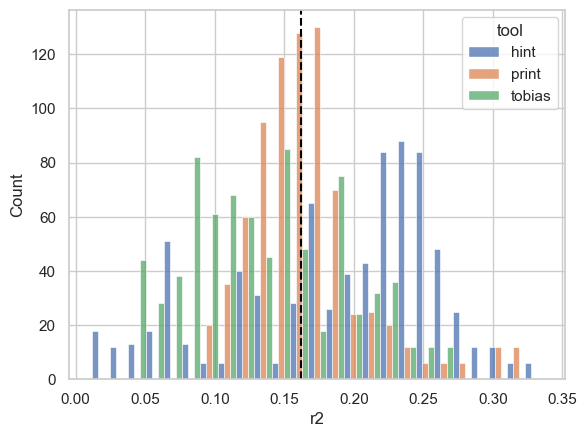

In [43]:
def _quickwrapper(tool, byGroup_df, mycolor="teal"):    
    values = byGroup_df[byGroup_df.tool==tool]['abs_coef_mean']
    errors = byGroup_df[byGroup_df.tool==tool]['abs_coef_sd']
    labels = byGroup_df[byGroup_df.tool==tool]['group']
    
    num_bars = len(values)
    angles = np.linspace(0, 2 * np.pi, num_bars, endpoint=False)
    width = 2 * np.pi / num_bars
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    bars = ax.bar(angles, values, width=width, color=mycolor, alpha=0.7)

    for angle, mean, std in zip(angles, values, errors):
        ax.errorbar(x=angle, y=mean, yerr=std, fmt='none', ecolor='black', capsize=4, linewidth=1)

    # Set labels at the correct angles
    #ax.set_yticks([ 0.01, 0.02, 0.03, 0.04, 0.05, 0.06])
    
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])  # Optional: remove radial axis labels

    ax.set_title(tool)
    plt.show()

color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E", "pwm": "#97CECC"}

mean_df = coef_df.groupby(["group", "tool"])[["abs_coef"]].apply(lambda col: col.mean())
std_df  = coef_df.groupby(["group", "tool"])[["abs_coef"]].apply(lambda col: col.std())

byGroup_df = pd.concat([mean_df.add_suffix('_mean'), std_df.add_suffix('_sd')], axis=1)
byGroup_df.reset_index(inplace=True)
#display(byGroup_df)

_quickwrapper("hint", byGroup_df, color_scheme_prog["hint"])
_quickwrapper("tobias", byGroup_df, color_scheme_prog["tobias"])
_quickwrapper("print", byGroup_df, color_scheme_prog["print"])

fig = plt.figure()
gs = GridSpec(1, 1, figure=fig)
sns.set(style='whitegrid')
ax = fig.add_subplot(gs[0])
sns.histplot(coef_df, x="r2", hue="tool", multiple="dodge")
plt.axvline(x=coef_df["r2"].median(), color='black', linestyle='--')

plt.show()

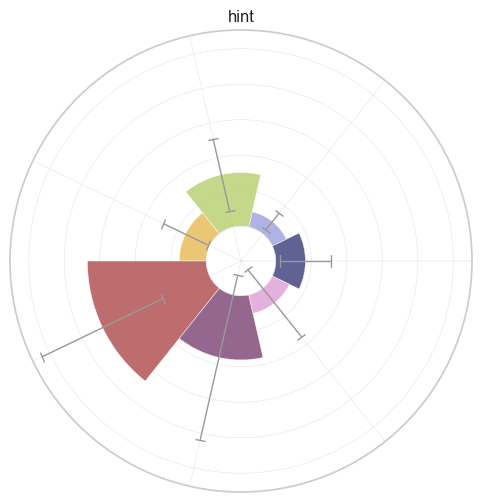

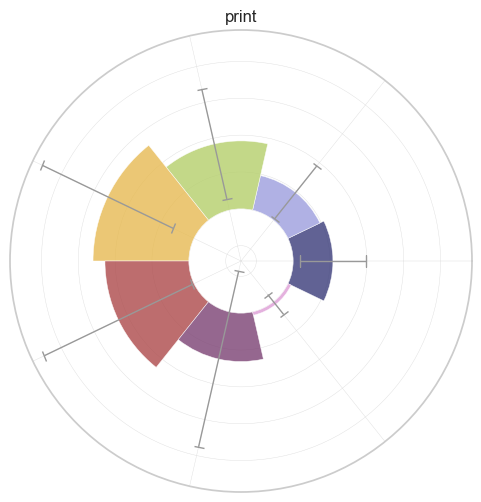

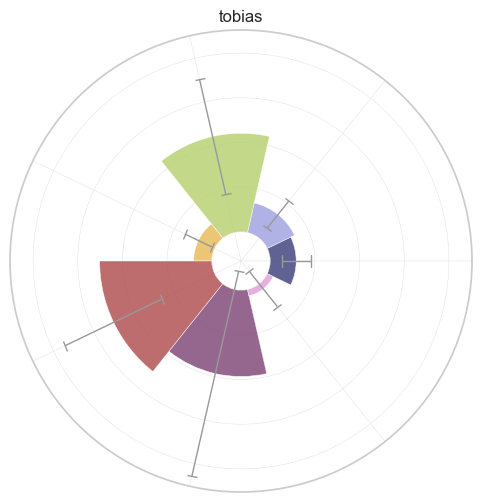

In [48]:
import matplotlib.colors as mcolors

def _quickwrapper(tool, byGroup_df):    
    values = byGroup_df[byGroup_df.tool==tool]['abs_coef_mean']
    errors = byGroup_df[byGroup_df.tool==tool]['abs_coef_sd']
    labels = byGroup_df[byGroup_df.tool==tool]['group']
    
    num_bars = len(values)
    angles = np.linspace(0, 2 * np.pi, num_bars, endpoint=False)
    width = 2 * np.pi / num_bars
    
    cmap = plt.cm.tab20b
    colors = [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, len(labels))]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    bars = ax.bar(angles, values, width=width, 
                  color=colors,
                  alpha=0.8, linewidth=0.4)

    for angle, mean, std in zip(angles, values, errors):
        ax.errorbar(x=angle, y=mean, yerr=std, fmt='none', ecolor='#999999', capsize=4, linewidth=1)
    
    ax.set_yticklabels([])  # Optional: remove radial axis labels
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.grid(which='major', color='#DDDDDD', linewidth=0.3)
    ax.set_xticklabels("")
    ax.set_title(tool)

    plt.show()

color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E", "pwm": "#97CECC"}

tmp = coef_df[coef_df.r2 > coef_df["r2"].median()]

mean_df = tmp.groupby(["group", "tool"])[["abs_coef"]].apply(lambda col: col.mean())
std_df  = tmp.groupby(["group", "tool"])[["abs_coef"]].apply(lambda col: col.std())
byGroup_df = pd.concat([mean_df.add_suffix('_mean'), std_df.add_suffix('_sd')], axis=1)
byGroup_df.reset_index(inplace=True)

_quickwrapper("hint", byGroup_df)
_quickwrapper("print", byGroup_df)
_quickwrapper("tobias", byGroup_df)